# 05 — Sparsity Analysis

## 1.1 Purpose

This notebook analyses how recommender-system performance changes under controlled reductions in user interaction histories.

The analysis considers three sparsity scenarios:

- **Random per-user sparsity (`global`)** — randomly retains interactions from each user's training history.
- **Recent-history sparsity (`recent`)** — retains the most recent training interactions.
- **Early-profile sparsity (`early`)** — retains the earliest training interactions, representing a cold-start-like limited-profile condition.

Nominal retention levels are 50%, 25%, and 10%, with the full 100% baseline used as the reference condition.

The notebook:

- analyses MovieLens and Amazon separately;
- plots NDCG@10 degradation across retention levels;
- compares absolute and relative performance changes;
- examines model ranking changes;
- measures seed variability;
- analyses unseen validation/test targets;
- compares the three sparsity mechanisms;
- checks whether conclusions remain consistent for Recall@10, MRR@10, and different recommendation-list lengths;
- exports analysis tables and figures for later dissertation use.

NDCG@10 is treated as the primary metric.

## 1.2 Setup

Load required libraries, locate the repository, and create directories for sparsity-analysis figures and tables.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


# ---------------------------------------------------------------------
# Locate repository root
# ---------------------------------------------------------------------

def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()

    for candidate in [start, *start.parents]:
        if (
            (candidate / "results").exists()
            and (candidate / "scripts").exists()
            and (candidate / "configs").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate repository root."
    )


ROOT = find_repo_root()

FIGURE_DIR = ROOT / "results" / "figures" / "sparsity"
TABLE_DIR = ROOT / "results" / "tables" / "sparsity"

for dataset in ["movielens", "amazon", "comparison"]:
    (FIGURE_DIR / dataset).mkdir(
        parents=True,
        exist_ok=True,
    )

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(f"Repository root : {ROOT}")
print(f"Figure directory: {FIGURE_DIR}")
print(f"Table directory : {TABLE_DIR}")


# ---------------------------------------------------------------------
# Plot defaults
# ---------------------------------------------------------------------

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.alpha": 0.25,
})

Repository root : C:\Research Project\recommender-sparsity-honours
Figure directory: C:\Research Project\recommender-sparsity-honours\results\figures\sparsity
Table directory : C:\Research Project\recommender-sparsity-honours\results\tables\sparsity


## 1.3 Verification status

Confirm that the final experiment set passed verification before analysing sparsity results.

In [2]:
verification_path = (
    ROOT
    / "results"
    / "verification"
    / "verification_summary.json"
)

if not verification_path.exists():
    raise FileNotFoundError(
        "verification_summary.json was not found. "
        "Run 03_results_verification.ipynb first."
    )

with open(
    verification_path,
    "r",
    encoding="utf-8",
) as f:
    verification = json.load(f)

print("Verification summary")
print("--------------------")
print(f"PASS : {verification['pass']}")
print(f"WARN : {verification['warn']}")
print(f"FAIL : {verification['fail']}")

if verification["fail"] > 0:
    raise RuntimeError(
        "Verification contains FAIL checks. "
        "Resolve these before sparsity analysis."
    )

print("\nVerification passed sufficiently for analysis.")

Verification summary
--------------------
PASS : 362
WARN : 2
FAIL : 0

Verification passed sufficiently for analysis.


## 1.4 Load final experiment results

Load all verified final MovieLens and Amazon results.

In [3]:
result_files = sorted(
    (ROOT / "results" / "processed").rglob(
        "all_final_results.csv"
    )
)

if not result_files:
    raise FileNotFoundError(
        "No all_final_results.csv files found."
    )

frames = []

for path in result_files:
    df = pd.read_csv(path)
    df["_source_file"] = str(
        path.relative_to(ROOT)
    )
    frames.append(df)

results = pd.concat(
    frames,
    ignore_index=True,
)

results["model_seed"] = pd.to_numeric(
    results["model_seed"],
    errors="coerce",
).astype("Int64")

results["retention_level"] = pd.to_numeric(
    results["retention_level"],
    errors="coerce",
).astype("Int64")


print(f"Final rows: {len(results)}")

display(
    results.groupby("dataset")
    .agg(
        rows=("model", "size"),
        models=("model", "nunique"),
        conditions=("dataset_directory", "nunique"),
    )
)

assert len(results) == 480
assert results["dataset"].nunique() == 2

print("\nFinal result set loaded correctly.")

Final rows: 480


,rows,models,conditions
dataset,,,
amazon,240,10,10
movielens,240,10,10



Final result set loaded correctly.


## 1.5 Analysis metadata

Define model families, scenario labels, and the consistent condition ordering used throughout the notebook.

In [5]:
MODEL_FAMILY = {
    "Pop": "Non-personalized",
    "ItemKNN": "Classical",
    "BPR": "Classical",
    "EASE": "Linear",
    "NeuMF": "Neural",
    "MultiVAE": "Neural",
    "GRU4Rec": "Sequential",
    "SASRec": "Sequential",
    "BERT4Rec": "Sequential",
    "LightGCN": "Graph",
}

MODEL_ORDER = [
    "Pop",
    "ItemKNN",
    "BPR",
    "EASE",
    "NeuMF",
    "MultiVAE",
    "GRU4Rec",
    "SASRec",
    "BERT4Rec",
    "LightGCN",
]

STOCHASTIC_MODELS = {
    "BPR",
    "NeuMF",
    "MultiVAE",
    "GRU4Rec",
    "SASRec",
    "BERT4Rec",
    "LightGCN",
}

SCENARIO_LABELS = {
    "baseline": "Baseline",
    "global": "Random per-user",
    "recent": "Recent-history",
    "early": "Early-profile",
}

SPARSE_SCENARIOS = [
    "global",
    "recent",
    "early",
]

RETENTION_ORDER = [
    100,
    50,
    25,
    10,
]

CONDITION_ORDER = [
    ("baseline", 100),
    ("global", 50),
    ("global", 25),
    ("global", 10),
    ("recent", 50),
    ("recent", 25),
    ("recent", 10),
    ("early", 50),
    ("early", 25),
    ("early", 10),
]


def condition_label(scenario, retention):
    if scenario == "baseline":
        return "Baseline"

    return (
        f"{SCENARIO_LABELS[scenario]} "
        f"{int(retention)}%"
    )


results["model_family"] = (
    results["model"]
    .map(MODEL_FAMILY)
)

results["condition_label"] = [
    condition_label(s, r)
    for s, r in zip(
        results["scenario"],
        results["retention_level"],
    )
]

assert results["model_family"].notna().all()

# 2. Sparsity Data Preparation

## 2.1 Model-level summary statistics

Calculate mean, sample standard deviation, range, relative change, and rank for every model under every experimental condition.

Relative change is expressed so that:

- negative values indicate performance degradation;
- positive values indicate improvement over baseline.

In [6]:
ANALYSIS_METRICS = [
    "test_ndcg@5",
    "test_ndcg@10",
    "test_ndcg@20",
    "test_recall@10",
    "test_mrr@10",
]


# Convert stored degradation into intuitive relative change.
results[
    "relative_change_ndcg10_pct"
] = (
    -100
    * results[
        "relative_drop_test_ndcg@10"
    ]
)

results[
    "relative_change_recall10_pct"
] = (
    -100
    * results[
        "relative_drop_test_recall@10"
    ]
)

results[
    "relative_change_mrr10_pct"
] = (
    -100
    * results[
        "relative_drop_test_mrr@10"
    ]
)


summary_rows = []

for (
    dataset,
    scenario,
    retention,
    model,
), group in results.groupby(
    [
        "dataset",
        "scenario",
        "retention_level",
        "model",
    ]
):

    row = {
        "dataset": dataset,
        "scenario": scenario,
        "scenario_label": SCENARIO_LABELS[
            scenario
        ],
        "retention_level": int(retention),
        "condition_label": condition_label(
            scenario,
            retention,
        ),
        "model": model,
        "model_family": MODEL_FAMILY[model],
        "runs": len(group),
        "actual_retention_percent": (
            group[
                "actual_training_retention_percent"
            ].iloc[0]
        ),
    }

    for metric in ANALYSIS_METRICS:
        values = group[metric].astype(float)

        row[f"{metric}_mean"] = values.mean()
        row[f"{metric}_std"] = (
            values.std(ddof=1)
            if len(values) > 1
            else np.nan
        )
        row[f"{metric}_min"] = values.min()
        row[f"{metric}_max"] = values.max()

    for change_metric in [
        "relative_change_ndcg10_pct",
        "relative_change_recall10_pct",
        "relative_change_mrr10_pct",
    ]:
        values = group[
            change_metric
        ].astype(float)

        row[
            f"{change_metric}_mean"
        ] = values.mean()

        row[
            f"{change_metric}_std"
        ] = (
            values.std(ddof=1)
            if len(values) > 1
            else np.nan
        )

    summary_rows.append(row)


sparsity_summary = pd.DataFrame(
    summary_rows
)


# ---------------------------------------------------------------------
# Add ranks within each experimental condition
# ---------------------------------------------------------------------

for metric in ANALYSIS_METRICS:
    sparsity_summary[
        f"{metric}_rank"
    ] = (
        sparsity_summary.groupby(
            [
                "dataset",
                "scenario",
                "retention_level",
            ]
        )[
            f"{metric}_mean"
        ]
        .rank(
            method="min",
            ascending=False,
        )
        .astype(int)
    )


assert len(sparsity_summary) == 200

display(
    sparsity_summary.head(20)
)

,dataset,scenario,scenario_label,retention_level,condition_label,model,model_family,runs,actual_retention_percent,test_ndcg@5_mean,...,relative_change_ndcg10_pct_std,relative_change_recall10_pct_mean,relative_change_recall10_pct_std,relative_change_mrr10_pct_mean,relative_change_mrr10_pct_std,test_ndcg@5_rank,test_ndcg@10_rank,test_ndcg@20_rank,test_recall@10_rank,test_mrr@10_rank
0,amazon,baseline,Baseline,100,Baseline,BERT4Rec,Sequential,3,100.000000,0.030387,...,0.000000,0.000000,0.000000,0.000000,0.000000,4,4,3,3,4
1,amazon,baseline,Baseline,100,Baseline,BPR,Classical,3,100.000000,0.028151,...,0.000000,0.000000,0.000000,0.000000,0.000000,6,6,6,6,6
2,amazon,baseline,Baseline,100,Baseline,EASE,Linear,1,100.000000,0.032719,...,NaN,0.000000,NaN,0.000000,NaN,3,3,4,4,3
3,amazon,baseline,Baseline,100,Baseline,GRU4Rec,Sequential,3,100.000000,0.034953,...,0.000000,0.000000,0.000000,0.000000,0.000000,1,2,2,2,1
4,amazon,baseline,Baseline,100,Baseline,ItemKNN,Classical,1,100.000000,0.019178,...,NaN,0.000000,NaN,0.000000,NaN,8,9,9,9,8
5,amazon,baseline,Baseline,100,Baseline,LightGCN,Graph,3,100.000000,0.028336,...,0.000000,0.000000,0.000000,0.000000,0.000000,5,5,5,5,5
6,amazon,baseline,Baseline,100,Baseline,MultiVAE,Neural,3,100.000000,0.027229,...,0.000000,0.000000,0.000000,0.000000,0.000000,7,7,7,7,7
7,amazon,baseline,Baseline,100,Baseline,NeuMF,Neural,3,100.000000,0.018951,...,0.000000,0.000000,0.000000,0.000000,0.000000,9,8,8,8,9
8,amazon,baseline,Baseline,100,Baseline,Pop,Non-personalized,1,100.000000,0.011771,...,NaN,0.000000,NaN,0.000000,NaN,10,10,10,10,10
9,amazon,baseline,Baseline,100,Baseline,SASRec,Sequential,3,100.000000,0.034908,...,0.000000,0.000000,0.000000,0.000000,0.000000,2,1,1,1,2


## 2.2 Condition-level dataset statistics

Independently reconstruct the temporal training, validation, and test partitions from each RecBole `.inter` file.

For every condition, calculate:

- number of retained training interactions;
- mean retained training interactions per user;
- number of unique training items;
- percentage of validation targets unseen in training;
- percentage of test targets unseen in training;
- actual aggregate training retention.

In [7]:
def normalise_recbole_columns(df):
    return df.rename(
        columns={
            c: c.split(":")[0]
            for c in df.columns
        }
    )


def read_recbole_table(path):
    return normalise_recbole_columns(
        pd.read_csv(
            path,
            sep="\t",
            low_memory=False,
        )
    )


def find_single_file(directory, suffix):
    files = sorted(
        Path(directory).glob(
            f"*{suffix}"
        )
    )

    if len(files) != 1:
        raise FileNotFoundError(
            f"Expected exactly one {suffix} "
            f"file in {directory}; found {len(files)}."
        )

    return files[0]


def split_leave_one_out(df):
    ordered = df.sort_values(
        [
            "user_id",
            "sequence_order",
        ],
        kind="mergesort",
    ).copy()

    ordered["_position"] = (
        ordered.groupby(
            "user_id",
            sort=False,
        )
        .cumcount()
    )

    ordered["_history_size"] = (
        ordered.groupby(
            "user_id",
            sort=False,
        )["user_id"]
        .transform("size")
    )

    ordered["_from_end"] = (
        ordered["_history_size"]
        - ordered["_position"]
        - 1
    )

    train = ordered[
        ordered["_from_end"] >= 2
    ].copy()

    validation = ordered[
        ordered["_from_end"] == 1
    ].copy()

    test = ordered[
        ordered["_from_end"] == 0
    ].copy()

    return train, validation, test


condition_dirs = (
    results[
        [
            "dataset",
            "scenario",
            "retention_level",
            "dataset_directory",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "dataset",
            "scenario",
            "retention_level",
        ]
    )
)


condition_records = []

for _, row in condition_dirs.iterrows():

    dataset = row["dataset"]
    scenario = row["scenario"]
    retention = int(
        row["retention_level"]
    )

    directory = (
        ROOT
        / row["dataset_directory"]
    )

    inter_path = find_single_file(
        directory,
        ".inter",
    )

    inter = read_recbole_table(
        inter_path
    )

    train, validation, test = (
        split_leave_one_out(inter)
    )

    train_items = set(
        train["item_id"].astype(str)
    )

    validation_unseen = (
        ~validation[
            "item_id"
        ]
        .astype(str)
        .isin(train_items)
    )

    test_unseen = (
        ~test[
            "item_id"
        ]
        .astype(str)
        .isin(train_items)
    )

    condition_records.append({
        "dataset": dataset,
        "scenario": scenario,
        "scenario_label": (
            SCENARIO_LABELS[scenario]
        ),
        "retention_level": retention,
        "condition_label": condition_label(
            scenario,
            retention,
        ),
        "users": (
            inter["user_id"].nunique()
        ),
        "training_interactions": len(train),
        "training_unique_items": (
            train["item_id"].nunique()
        ),
        "mean_training_interactions_per_user": (
            len(train)
            / inter["user_id"].nunique()
        ),
        "validation_unseen_targets": (
            int(validation_unseen.sum())
        ),
        "validation_unseen_percent": (
            validation_unseen.mean()
            * 100
        ),
        "test_unseen_targets": (
            int(test_unseen.sum())
        ),
        "test_unseen_percent": (
            test_unseen.mean()
            * 100
        ),
    })


condition_data_stats = pd.DataFrame(
    condition_records
)


# Calculate actual retention relative to baseline training data.
baseline_train_counts = (
    condition_data_stats[
        condition_data_stats[
            "scenario"
        ] == "baseline"
    ]
    .set_index("dataset")[
        "training_interactions"
    ]
    .to_dict()
)

condition_data_stats[
    "actual_retention_percent"
] = condition_data_stats.apply(
    lambda row:
        row["training_interactions"]
        / baseline_train_counts[
            row["dataset"]
        ]
        * 100,
    axis=1,
)


assert len(condition_data_stats) == 20

display(
    condition_data_stats.sort_values(
        [
            "dataset",
            "scenario",
            "retention_level",
        ]
    )
)

,dataset,scenario,scenario_label,retention_level,condition_label,users,training_interactions,training_unique_items,mean_training_interactions_per_user,validation_unseen_targets,validation_unseen_percent,test_unseen_targets,test_unseen_percent,actual_retention_percent
0,amazon,baseline,Baseline,100,Baseline,63413,406724,18966,6.413890,110,0.173466,227,0.357971,100.000000
1,amazon,early,Early-profile,10,Early-profile 10%,63413,74756,14478,1.178875,6483,10.223456,8356,13.177109,18.380032
2,amazon,early,Early-profile,25,Early-profile 25%,63413,121068,16375,1.909198,3934,6.203775,5467,8.621261,29.766623
3,amazon,early,Early-profile,50,Early-profile 50%,63413,222525,18184,3.509139,1311,2.067399,2112,3.330547,54.711549
4,amazon,global,Random per-user,10,Random per-user 10%,63413,74756,15029,1.178875,4686,7.389652,5752,9.070695,18.380032
5,amazon,global,Random per-user,25,Random per-user 25%,63413,121068,17109,1.909198,2348,3.702711,3100,4.888588,29.766623
6,amazon,global,Random per-user,50,Random per-user 50%,63413,222525,18565,3.509139,680,1.072335,1057,1.666851,54.711549
7,amazon,recent,Recent-history,10,Recent-history 10%,63413,74756,14919,1.178875,3996,6.301547,4372,6.894485,18.380032
8,amazon,recent,Recent-history,25,Recent-history 25%,63413,121068,17075,1.909198,1849,2.915806,2093,3.300585,29.766623
9,amazon,recent,Recent-history,50,Recent-history 50%,63413,222525,18604,3.509139,479,0.755366,708,1.116490,54.711549


## 2.3 Shared plotting helpers

Define reusable plotting functions so that MovieLens and Amazon use exactly the same analysis procedure.

In [8]:
def save_figure(
    fig,
    dataset,
    filename,
):
    directory = (
        FIGURE_DIR / dataset
    )

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig.savefig(
        directory / f"{filename}.png",
        bbox_inches="tight",
    )

    fig.savefig(
        directory / f"{filename}.pdf",
        bbox_inches="tight",
    )


def baseline_model_order(
    summary,
    dataset,
):
    return (
        summary[
            (summary["dataset"] == dataset)
            & (
                summary["scenario"]
                == "baseline"
            )
        ]
        .sort_values(
            "test_ndcg@10_mean",
            ascending=False,
        )["model"]
        .tolist()
    )


def plot_sparsity_curve(
    summary,
    dataset,
    scenario,
    metric,
    metric_label,
    filename,
):

    x_labels = [
        "100",
        "50",
        "25",
        "10",
    ]

    x = np.arange(
        len(x_labels)
    )

    model_order = baseline_model_order(
        summary,
        dataset,
    )

    fig, ax = plt.subplots(
        figsize=(11, 7)
    )

    for model in model_order:

        means = []
        errors = []

        for retention in RETENTION_ORDER:

            if retention == 100:
                condition = summary[
                    (summary["dataset"] == dataset)
                    & (
                        summary["scenario"]
                        == "baseline"
                    )
                    & (
                        summary["model"]
                        == model
                    )
                ]
            else:
                condition = summary[
                    (summary["dataset"] == dataset)
                    & (
                        summary["scenario"]
                        == scenario
                    )
                    & (
                        summary["retention_level"]
                        == retention
                    )
                    & (
                        summary["model"]
                        == model
                    )
                ]

            if len(condition) != 1:
                raise ValueError(
                    f"Expected one row for "
                    f"{dataset}/{scenario}/"
                    f"{retention}/{model}"
                )

            means.append(
                condition[
                    f"{metric}_mean"
                ].iloc[0]
            )

            std = condition[
                f"{metric}_std"
            ].iloc[0]

            errors.append(
                0
                if pd.isna(std)
                else std
            )

        ax.errorbar(
            x,
            means,
            yerr=errors,
            marker="o",
            capsize=2,
            linewidth=1.5,
            label=model,
        )

    dataset_title = (
        "MovieLens-1M"
        if dataset == "movielens"
        else "Amazon Video Games"
    )

    ax.set_xticks(
        x,
        x_labels,
    )

    ax.set_xlabel(
        "Nominal training retention (%)"
    )

    ax.set_ylabel(
        metric_label
    )

    ax.set_title(
        f"{dataset_title}: "
        f"{SCENARIO_LABELS[scenario]} sparsity"
    )

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    fig.tight_layout()

    save_figure(
        fig,
        dataset,
        filename,
    )

    plt.show()


def plot_relative_change_heatmap(
    summary,
    dataset,
    filename,
):

    column_conditions = [
        ("global", 50),
        ("global", 25),
        ("global", 10),
        ("recent", 50),
        ("recent", 25),
        ("recent", 10),
        ("early", 50),
        ("early", 25),
        ("early", 10),
    ]

    model_order = baseline_model_order(
        summary,
        dataset,
    )

    matrix = []

    for model in model_order:
        values = []

        for scenario, retention in column_conditions:

            row = summary[
                (summary["dataset"] == dataset)
                & (
                    summary["scenario"]
                    == scenario
                )
                & (
                    summary["retention_level"]
                    == retention
                )
                & (
                    summary["model"]
                    == model
                )
            ]

            values.append(
                row[
                    "relative_change_ndcg10_pct_mean"
                ].iloc[0]
            )

        matrix.append(values)

    matrix = np.array(matrix)

    max_abs = np.nanmax(
        np.abs(matrix)
    )

    labels = [
        "Random\n50%",
        "Random\n25%",
        "Random\n10%",
        "Recent\n50%",
        "Recent\n25%",
        "Recent\n10%",
        "Early\n50%",
        "Early\n25%",
        "Early\n10%",
    ]

    fig, ax = plt.subplots(
        figsize=(12, 7)
    )

    image = ax.imshow(
        matrix,
        aspect="auto",
        cmap="RdYlGn",
        vmin=-max_abs,
        vmax=max_abs,
    )

    ax.set_xticks(
        np.arange(len(labels)),
        labels,
    )

    ax.set_yticks(
        np.arange(len(model_order)),
        model_order,
    )

    for i in range(
        matrix.shape[0]
    ):
        for j in range(
            matrix.shape[1]
        ):
            ax.text(
                j,
                i,
                f"{matrix[i, j]:+.1f}%",
                ha="center",
                va="center",
                fontsize=8,
            )

    dataset_title = (
        "MovieLens-1M"
        if dataset == "movielens"
        else "Amazon Video Games"
    )

    ax.set_title(
        f"{dataset_title}: "
        "relative NDCG@10 change from baseline"
    )

    cbar = fig.colorbar(
        image,
        ax=ax,
    )

    cbar.set_label(
        "Relative NDCG@10 change (%)"
    )

    fig.tight_layout()

    save_figure(
        fig,
        dataset,
        filename,
    )

    plt.show()


def create_rank_table(
    summary,
    dataset,
):

    labels = {
        ("baseline", 100): "Baseline",
        ("global", 50): "Random 50",
        ("global", 25): "Random 25",
        ("global", 10): "Random 10",
        ("recent", 50): "Recent 50",
        ("recent", 25): "Recent 25",
        ("recent", 10): "Recent 10",
        ("early", 50): "Early 50",
        ("early", 25): "Early 25",
        ("early", 10): "Early 10",
    }

    rows = []

    for model in baseline_model_order(
        summary,
        dataset,
    ):
        row = {
            "Model": model,
            "Family": MODEL_FAMILY[
                model
            ],
        }

        for condition, label in labels.items():

            scenario, retention = (
                condition
            )

            value = summary[
                (summary["dataset"] == dataset)
                & (
                    summary["scenario"]
                    == scenario
                )
                & (
                    summary["retention_level"]
                    == retention
                )
                & (
                    summary["model"]
                    == model
                )
            ][
                "test_ndcg@10_rank"
            ].iloc[0]

            row[label] = int(value)

        rows.append(row)

    return pd.DataFrame(rows)


def plot_rank_heatmap(
    rank_table,
    dataset,
    filename,
):

    matrix = rank_table.drop(
        columns=[
            "Model",
            "Family",
        ]
    ).to_numpy()

    labels = [
        c
        for c in rank_table.columns
        if c not in [
            "Model",
            "Family",
        ]
    ]

    fig, ax = plt.subplots(
        figsize=(12, 7)
    )

    image = ax.imshow(
        matrix,
        aspect="auto",
        cmap="viridis_r",
        vmin=1,
        vmax=10,
    )

    ax.set_xticks(
        np.arange(len(labels)),
        labels,
        rotation=45,
        ha="right",
    )

    ax.set_yticks(
        np.arange(len(rank_table)),
        rank_table["Model"],
    )

    for i in range(
        matrix.shape[0]
    ):
        for j in range(
            matrix.shape[1]
        ):
            ax.text(
                j,
                i,
                str(int(matrix[i, j])),
                ha="center",
                va="center",
                fontsize=8,
            )

    dataset_title = (
        "MovieLens-1M"
        if dataset == "movielens"
        else "Amazon Video Games"
    )

    ax.set_title(
        f"{dataset_title}: "
        "NDCG@10 model rank by condition"
    )

    cbar = fig.colorbar(
        image,
        ax=ax,
    )

    cbar.set_label(
        "Rank (1 = best)"
    )

    fig.tight_layout()

    save_figure(
        fig,
        dataset,
        filename,
    )

    plt.show()


def plot_unseen_targets(
    condition_stats,
    dataset,
    filename,
):

    subset = condition_stats[
        condition_stats["dataset"]
        == dataset
    ]

    x_labels = [
        "100",
        "50",
        "25",
        "10",
    ]

    x = np.arange(
        len(x_labels)
    )

    fig, ax = plt.subplots(
        figsize=(9, 6)
    )

    baseline_value = subset[
        subset["scenario"]
        == "baseline"
    ]["test_unseen_percent"].iloc[0]

    for scenario in SPARSE_SCENARIOS:

        values = [
            baseline_value
        ]

        for retention in [
            50,
            25,
            10,
        ]:
            value = subset[
                (subset["scenario"] == scenario)
                & (
                    subset["retention_level"]
                    == retention
                )
            ][
                "test_unseen_percent"
            ].iloc[0]

            values.append(value)

        ax.plot(
            x,
            values,
            marker="o",
            label=SCENARIO_LABELS[
                scenario
            ],
        )

    ax.set_xticks(
        x,
        x_labels,
    )

    ax.set_xlabel(
        "Nominal training retention (%)"
    )

    ax.set_ylabel(
        "Test targets unseen in training (%)"
    )

    dataset_title = (
        "MovieLens-1M"
        if dataset == "movielens"
        else "Amazon Video Games"
    )

    ax.set_title(
        f"{dataset_title}: "
        "unseen test targets under sparsity"
    )

    ax.legend()

    fig.tight_layout()

    save_figure(
        fig,
        dataset,
        filename,
    )

    plt.show()

# 3. MovieLens Sparsity Analysis

## 3.1 Condition summary

Summarise the amount of MovieLens training data retained under each sparsity condition and the resulting item exposure.

In [9]:
movielens_conditions = (
    condition_data_stats[
        condition_data_stats["dataset"]
        == "movielens"
    ]
    .copy()
)

display(
    movielens_conditions[
        [
            "scenario_label",
            "retention_level",
            "actual_retention_percent",
            "training_interactions",
            "mean_training_interactions_per_user",
            "training_unique_items",
            "test_unseen_percent",
        ]
    ]
    .sort_values(
        [
            "scenario_label",
            "retention_level",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .style.format({
        "actual_retention_percent": "{:.3f}%",
        "mean_training_interactions_per_user": "{:.2f}",
        "test_unseen_percent": "{:.3f}%",
    })
)

,scenario_label,retention_level,actual_retention_percent,training_interactions,mean_training_interactions_per_user,training_unique_items,test_unseen_percent
10,Baseline,100,100.000%,562308,93.19,3125,0.000%
13,Early-profile,50,50.270%,282674,46.85,3105,0.099%
12,Early-profile,25,25.404%,142846,23.67,2986,0.563%
11,Early-profile,10,10.479%,58922,9.76,2693,2.320%
16,Random per-user,50,50.270%,282674,46.85,3122,0.033%
15,Random per-user,25,25.404%,142846,23.67,3065,0.265%
14,Random per-user,10,10.479%,58922,9.76,2853,1.425%
19,Recent-history,50,50.270%,282674,46.85,3124,0.000%
18,Recent-history,25,25.404%,142846,23.67,3102,0.066%
17,Recent-history,10,10.479%,58922,9.76,2971,0.580%


## 3.2 Random per-user sparsity

Analyse performance when interactions are randomly removed from each user's training history.

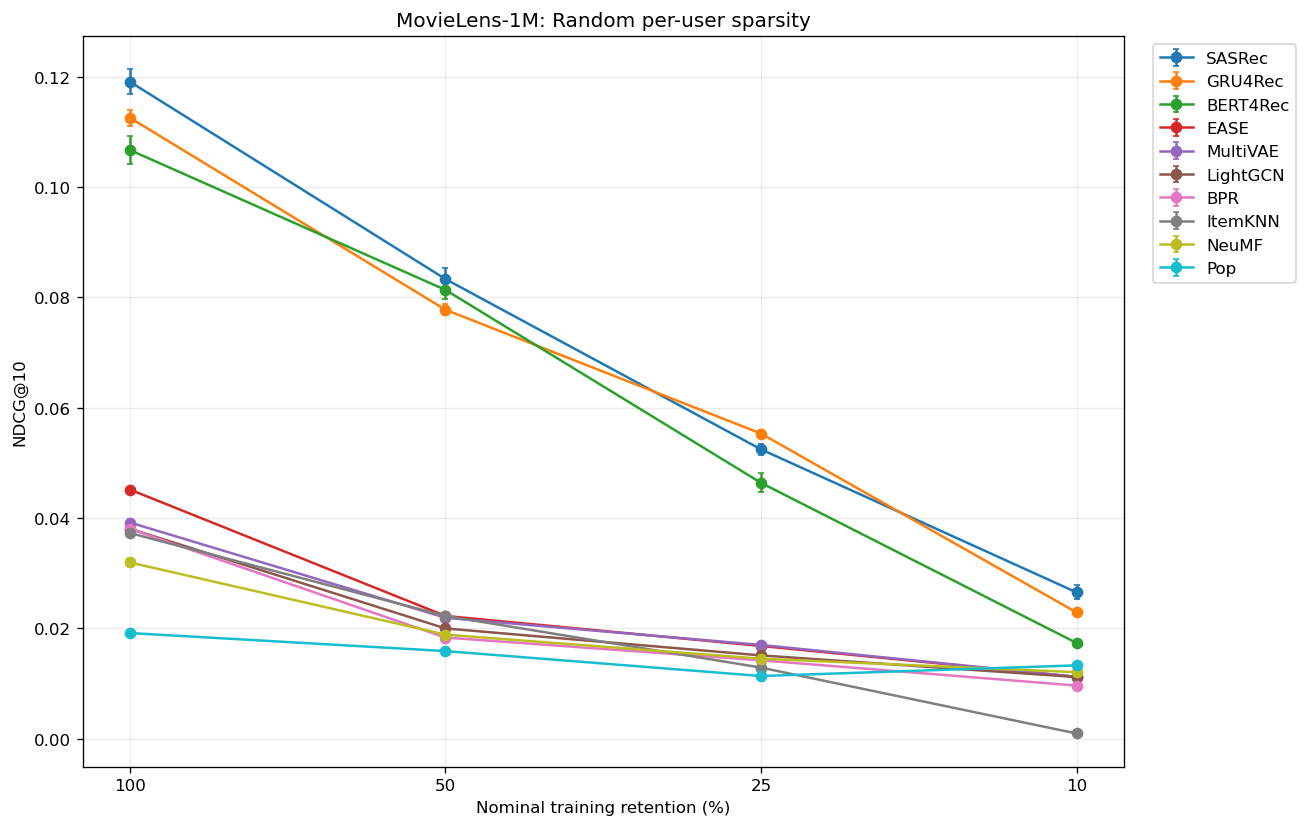

In [10]:
plot_sparsity_curve(
    sparsity_summary,
    dataset="movielens",
    scenario="global",
    metric="test_ndcg@10",
    metric_label="NDCG@10",
    filename="movielens_random_ndcg10",
)

## 3.3 Recent-history sparsity

Analyse performance when only the most recent training interactions are retained.

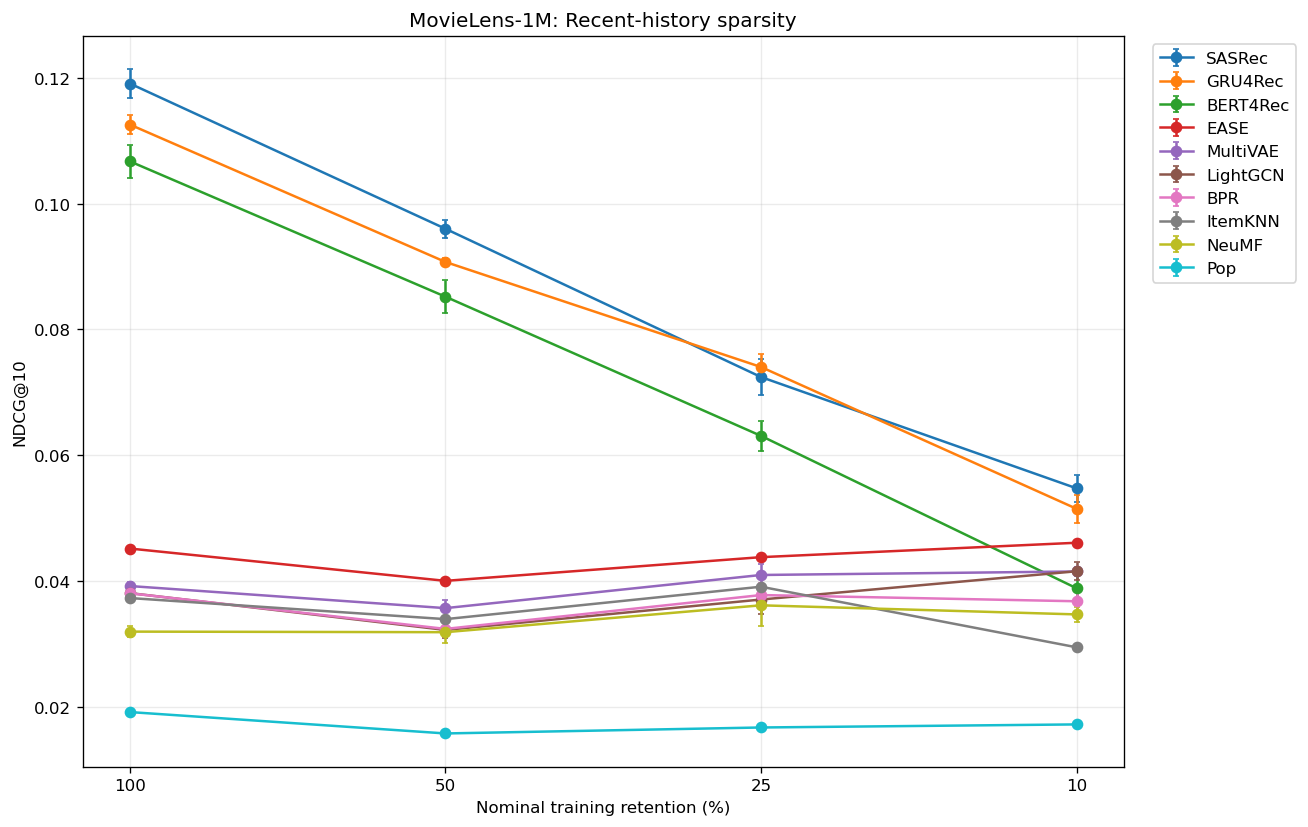

In [11]:
plot_sparsity_curve(
    sparsity_summary,
    dataset="movielens",
    scenario="recent",
    metric="test_ndcg@10",
    metric_label="NDCG@10",
    filename="movielens_recent_ndcg10",
)

## 3.4 Early-profile sparsity

Analyse performance when only the earliest training interactions are retained.

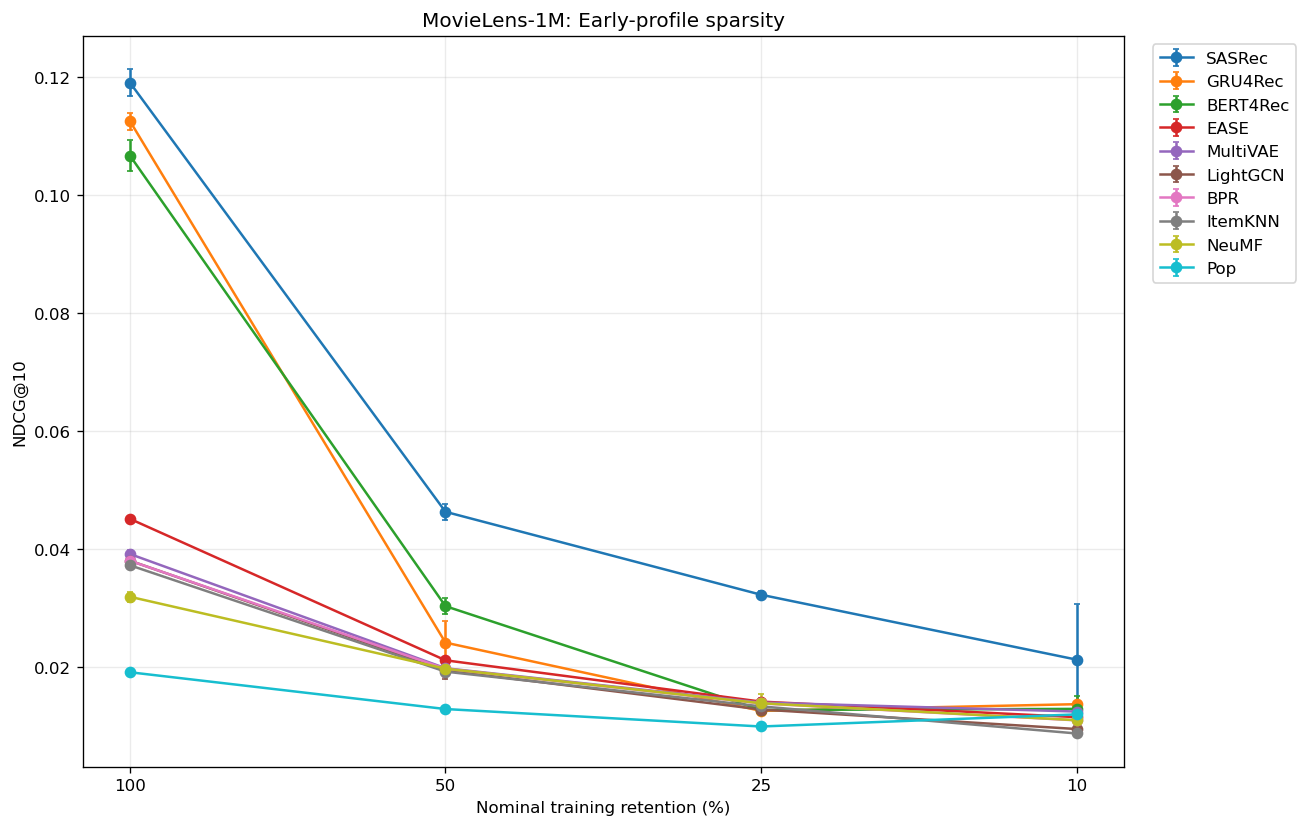

In [12]:
plot_sparsity_curve(
    sparsity_summary,
    dataset="movielens",
    scenario="early",
    metric="test_ndcg@10",
    metric_label="NDCG@10",
    filename="movielens_early_ndcg10",
)

## 3.5 Relative NDCG@10 change

Compare each model's percentage change from its own full-data baseline.

Negative values represent degradation. Positive values represent improvement.

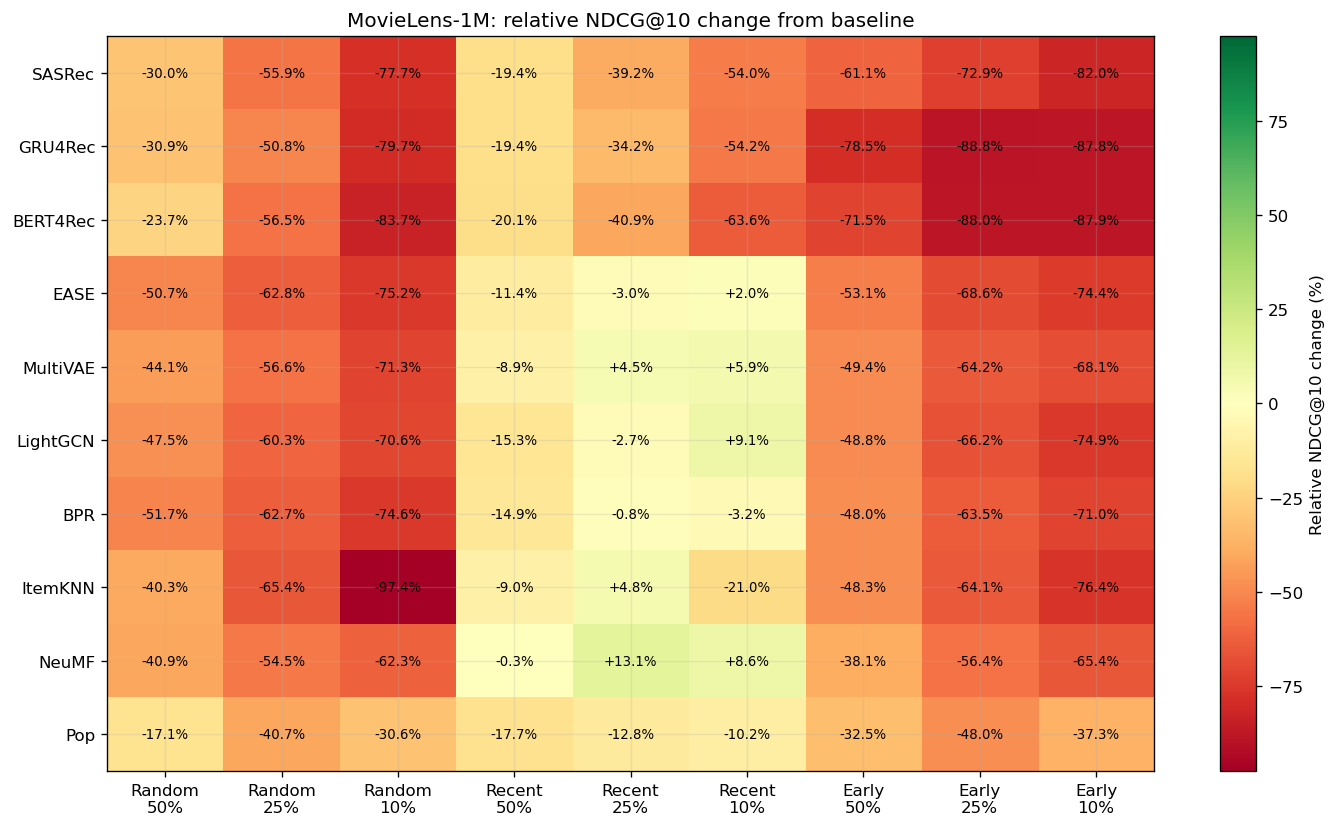

In [13]:
plot_relative_change_heatmap(
    sparsity_summary,
    dataset="movielens",
    filename="movielens_relative_ndcg_change_heatmap",
)

## 3.6 Model ranking changes

Examine whether sparsity changes the relative ranking of recommendation models.

,Model,Family,Baseline,Random 50,Random 25,Random 10,Recent 50,Recent 25,Recent 10,Early 50,Early 25,Early 10
0,SASRec,Sequential,1,1,2,1,1,2,1,1,1,1
1,GRU4Rec,Sequential,2,3,1,2,2,1,2,3,9,2
2,BERT4Rec,Sequential,3,2,3,3,3,3,6,2,8,3
3,EASE,Linear,4,4,5,7,4,4,3,4,2,6
4,MultiVAE,Neural,5,6,4,6,5,5,5,5,3,4
5,LightGCN,Graph,6,7,6,8,8,8,4,8,7,9
6,BPR,Classical,7,9,8,9,7,7,7,7,5,8
7,ItemKNN,Classical,8,5,9,10,6,6,9,9,6,10
8,NeuMF,Neural,9,8,7,5,9,9,8,6,4,7
9,Pop,Non-personalized,10,10,10,4,10,10,10,10,10,5


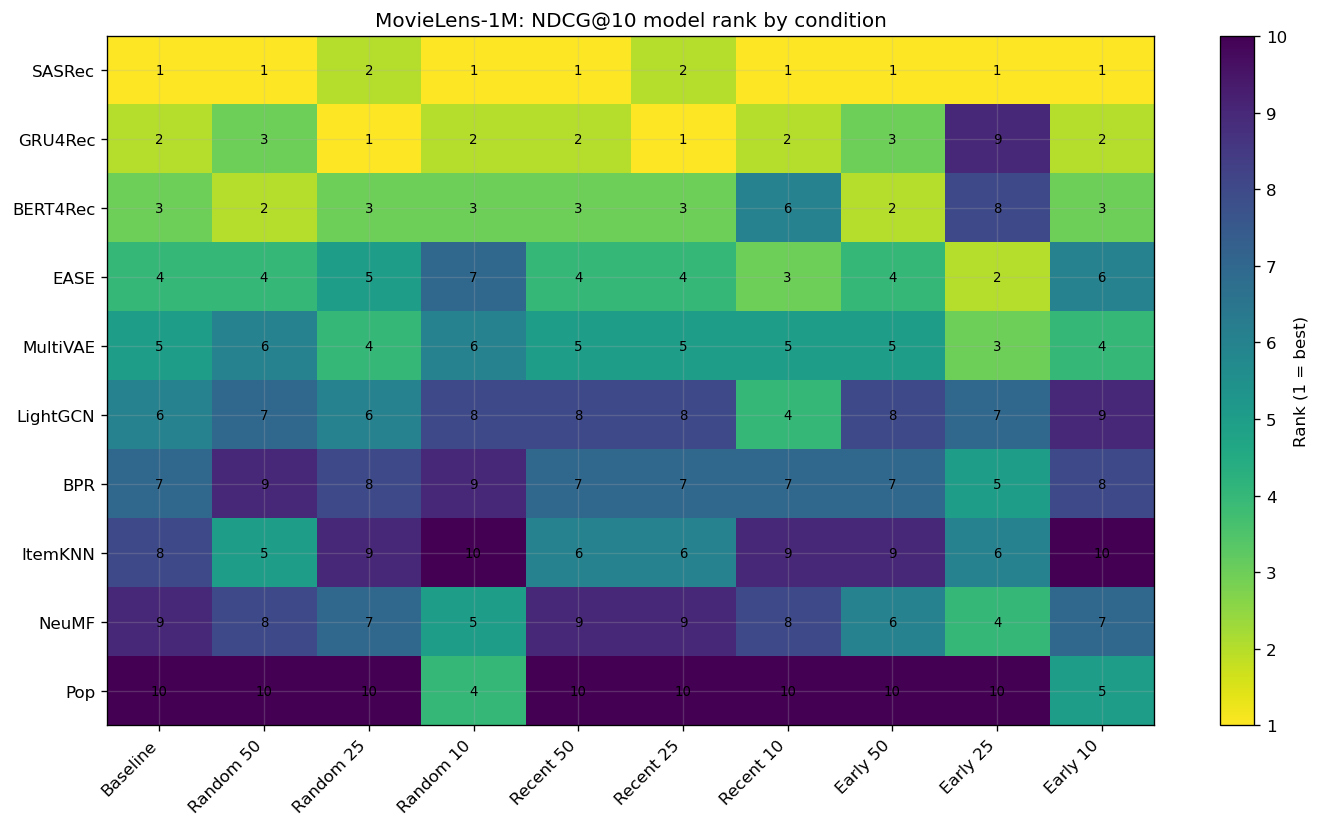

In [14]:
movielens_rank_table = (
    create_rank_table(
        sparsity_summary,
        "movielens",
    )
)

display(
    movielens_rank_table
)

plot_rank_heatmap(
    movielens_rank_table,
    dataset="movielens",
    filename="movielens_ndcg_rank_heatmap",
)

## 3.7 Seed variability

Identify stochastic models and sparse conditions with the greatest run-to-run variation in NDCG@10.

In [15]:
def create_sparse_seed_variability(
    summary,
    dataset,
):

    table = summary[
        (summary["dataset"] == dataset)
        & (
            summary["scenario"]
            != "baseline"
        )
        & (
            summary["runs"] > 1
        )
    ].copy()

    table[
        "ndcg_cv_percent"
    ] = (
        table[
            "test_ndcg@10_std"
        ]
        / table[
            "test_ndcg@10_mean"
        ]
        * 100
    )

    return (
        table[
            [
                "scenario_label",
                "retention_level",
                "model",
                "test_ndcg@10_mean",
                "test_ndcg@10_std",
                "ndcg_cv_percent",
            ]
        ]
        .sort_values(
            "ndcg_cv_percent",
            ascending=False,
        )
        .reset_index(drop=True)
    )


movielens_seed_variability = (
    create_sparse_seed_variability(
        sparsity_summary,
        "movielens",
    )
)

display(
    movielens_seed_variability.head(15)
    .style.format({
        "test_ndcg@10_mean": "{:.6f}",
        "test_ndcg@10_std": "{:.6f}",
        "ndcg_cv_percent": "{:.2f}%",
    })
)

,scenario_label,retention_level,model,test_ndcg@10_mean,test_ndcg@10_std,ndcg_cv_percent
0,Early-profile,10,SASRec,0.021299,0.009363,43.96%
1,Early-profile,10,BERT4Rec,0.012949,0.002247,17.35%
2,Early-profile,50,GRU4Rec,0.024181,0.003654,15.11%
3,Random per-user,10,NeuMF,0.012062,0.001589,13.18%
4,Random per-user,25,LightGCN,0.015103,0.001894,12.54%
5,Early-profile,25,NeuMF,0.013909,0.001554,11.17%
6,Random per-user,25,BPR,0.014214,0.001337,9.40%
7,Recent-history,25,NeuMF,0.036131,0.003340,9.24%
8,Random per-user,25,NeuMF,0.014506,0.001231,8.49%
9,Early-profile,10,NeuMF,0.011035,0.000885,8.02%


## 3.8 Unseen-target analysis

Measure how frequently held-out test items become completely unseen in the retained training data as sparsity increases.

This helps distinguish the effect of shorter user histories from the additional difficulty caused by reduced item exposure.

,scenario_label,retention_level,training_unique_items,validation_unseen_percent,test_unseen_percent
10,Baseline,100,3125,0.000%,0.000%
13,Early-profile,50,3105,0.033%,0.099%
12,Early-profile,25,2986,0.431%,0.563%
11,Early-profile,10,2693,2.005%,2.320%
16,Random per-user,50,3122,0.000%,0.033%
15,Random per-user,25,3065,0.149%,0.265%
14,Random per-user,10,2853,0.928%,1.425%
19,Recent-history,50,3124,0.000%,0.000%
18,Recent-history,25,3102,0.033%,0.066%
17,Recent-history,10,2971,0.464%,0.580%


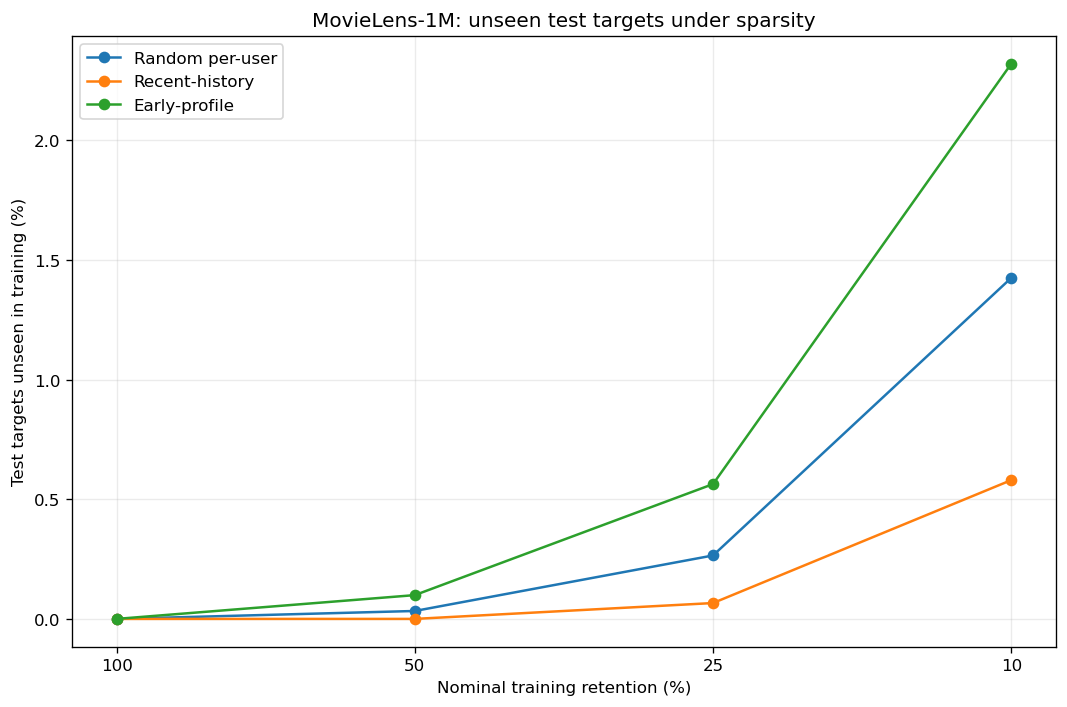

In [16]:
display(
    movielens_conditions[
        [
            "scenario_label",
            "retention_level",
            "training_unique_items",
            "validation_unseen_percent",
            "test_unseen_percent",
        ]
    ]
    .sort_values(
        [
            "scenario_label",
            "retention_level",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .style.format({
        "validation_unseen_percent": "{:.3f}%",
        "test_unseen_percent": "{:.3f}%",
    })
)

plot_unseen_targets(
    condition_data_stats,
    dataset="movielens",
    filename="movielens_unseen_test_targets",
)

## 3.9 Unseen targets and performance

Calculate the Spearman association between the percentage of unseen test targets and model performance across the nine sparse MovieLens conditions.

These correlations are descriptive associations and should not be interpreted as causal effects.

In [17]:
def unseen_performance_correlations(
    summary,
    condition_stats,
    dataset,
):

    condition_subset = condition_stats[
        (condition_stats["dataset"] == dataset)
        & (
            condition_stats["scenario"]
            != "baseline"
        )
    ][
        [
            "scenario",
            "retention_level",
            "test_unseen_percent",
        ]
    ]

    rows = []

    for model in MODEL_ORDER:

        model_results = summary[
            (summary["dataset"] == dataset)
            & (
                summary["scenario"]
                != "baseline"
            )
            & (
                summary["model"]
                == model
            )
        ].merge(
            condition_subset,
            on=[
                "scenario",
                "retention_level",
            ],
            how="left",
        )

        rows.append({
            "Model": model,
            "Family": MODEL_FAMILY[
                model
            ],
            "Unseen vs NDCG@10": (
                model_results[
                    "test_unseen_percent"
                ]
                .corr(
                    model_results[
                        "test_ndcg@10_mean"
                    ],
                    method="spearman",
                )
            ),
            "Unseen vs Relative Change": (
                model_results[
                    "test_unseen_percent"
                ]
                .corr(
                    model_results[
                        "relative_change_ndcg10_pct_mean"
                    ],
                    method="spearman",
                )
            ),
        })

    return pd.DataFrame(rows)


movielens_unseen_correlations = (
    unseen_performance_correlations(
        sparsity_summary,
        condition_data_stats,
        "movielens",
    )
)

display(
    movielens_unseen_correlations
    .style.format({
        "Unseen vs NDCG@10": "{:.3f}",
        "Unseen vs Relative Change": "{:.3f}",
    })
)

,Model,Family,Unseen vs NDCG@10,Unseen vs Relative Change
0,Pop,Non-personalized,-0.317,-0.317
1,ItemKNN,Classical,-0.733,-0.733
2,BPR,Classical,-0.617,-0.617
3,EASE,Linear,-0.583,-0.583
4,NeuMF,Neural,-0.633,-0.633
5,MultiVAE,Neural,-0.583,-0.583
6,GRU4Rec,Sequential,-0.833,-0.833
7,SASRec,Sequential,-0.883,-0.883
8,BERT4Rec,Sequential,-0.833,-0.833
9,LightGCN,Graph,-0.600,-0.600


## 3.10 MovieLens findings

Record the main MovieLens sparsity observations:

- How quickly does performance decline as retention decreases?
- Which sparsity scenario is least damaging?
- Which scenario is most damaging?
- Which models retain the strongest absolute NDCG@10?
- Which models show the smallest relative degradation?
- Do any models improve under recent-history sparsity?
- Which models experience major ranking changes?
- Does seed variability increase under severe sparsity?
- Does the percentage of unseen test targets increase with sparsity?
- Is greater unseen-target exposure associated with lower performance?

These observations will later be converted into the MovieLens sparsity subsection of the Results and Discussion chapters.

# 4. Amazon Sparsity Analysis

## 4.1 Condition summary

Summarise the amount of Amazon training data retained under each condition.

Because Amazon user histories are short, the per-user ceiling rule causes actual aggregate retention to differ substantially from the nominal retention percentage.

In [18]:
amazon_conditions = (
    condition_data_stats[
        condition_data_stats["dataset"]
        == "amazon"
    ]
    .copy()
)

display(
    amazon_conditions[
        [
            "scenario_label",
            "retention_level",
            "actual_retention_percent",
            "training_interactions",
            "mean_training_interactions_per_user",
            "training_unique_items",
            "test_unseen_percent",
        ]
    ]
    .sort_values(
        [
            "scenario_label",
            "retention_level",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .style.format({
        "actual_retention_percent": "{:.3f}%",
        "mean_training_interactions_per_user": "{:.2f}",
        "test_unseen_percent": "{:.3f}%",
    })
)

,scenario_label,retention_level,actual_retention_percent,training_interactions,mean_training_interactions_per_user,training_unique_items,test_unseen_percent
0,Baseline,100,100.000%,406724,6.41,18966,0.358%
3,Early-profile,50,54.712%,222525,3.51,18184,3.331%
2,Early-profile,25,29.767%,121068,1.91,16375,8.621%
1,Early-profile,10,18.380%,74756,1.18,14478,13.177%
6,Random per-user,50,54.712%,222525,3.51,18565,1.667%
5,Random per-user,25,29.767%,121068,1.91,17109,4.889%
4,Random per-user,10,18.380%,74756,1.18,15029,9.071%
9,Recent-history,50,54.712%,222525,3.51,18604,1.116%
8,Recent-history,25,29.767%,121068,1.91,17075,3.301%
7,Recent-history,10,18.380%,74756,1.18,14919,6.894%


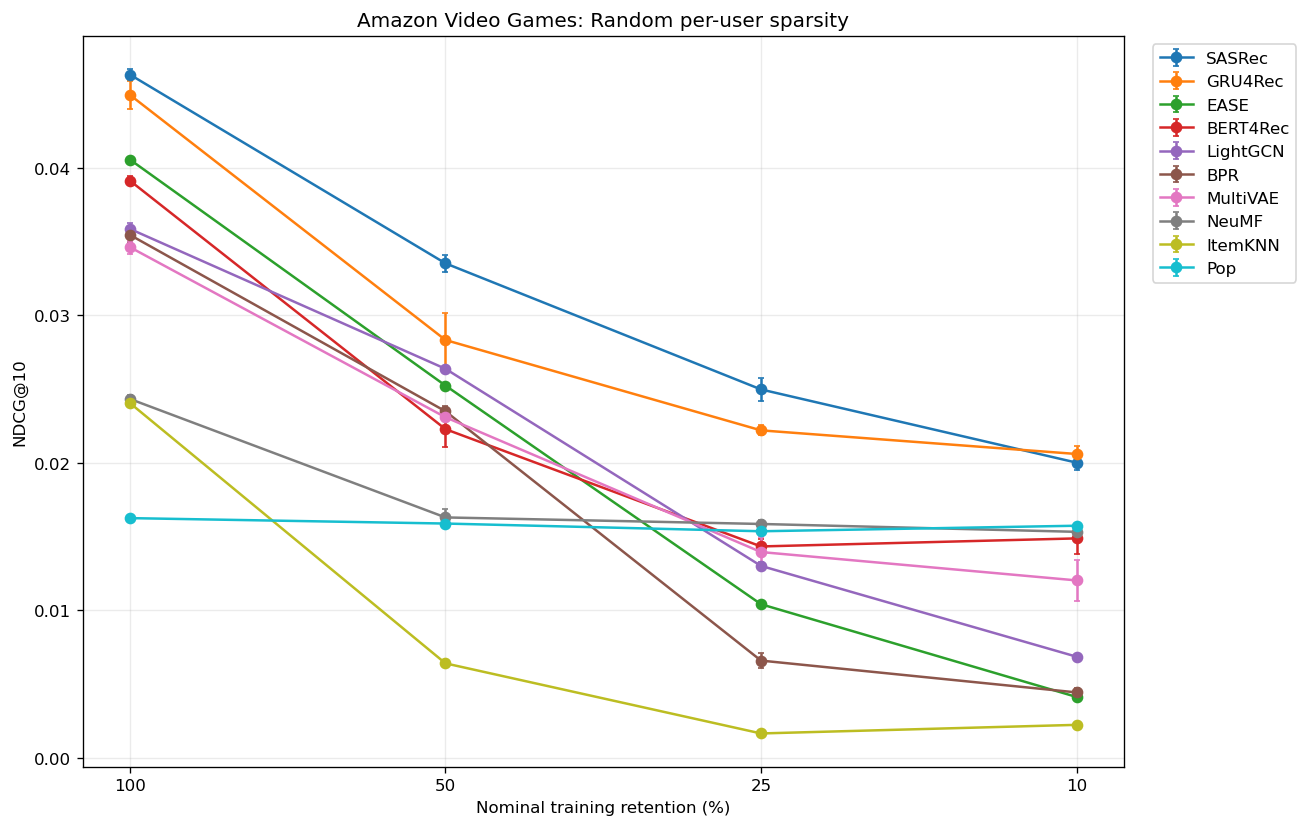

In [19]:
plot_sparsity_curve(
    sparsity_summary,
    dataset="amazon",
    scenario="global",
    metric="test_ndcg@10",
    metric_label="NDCG@10",
    filename="amazon_random_ndcg10",
)

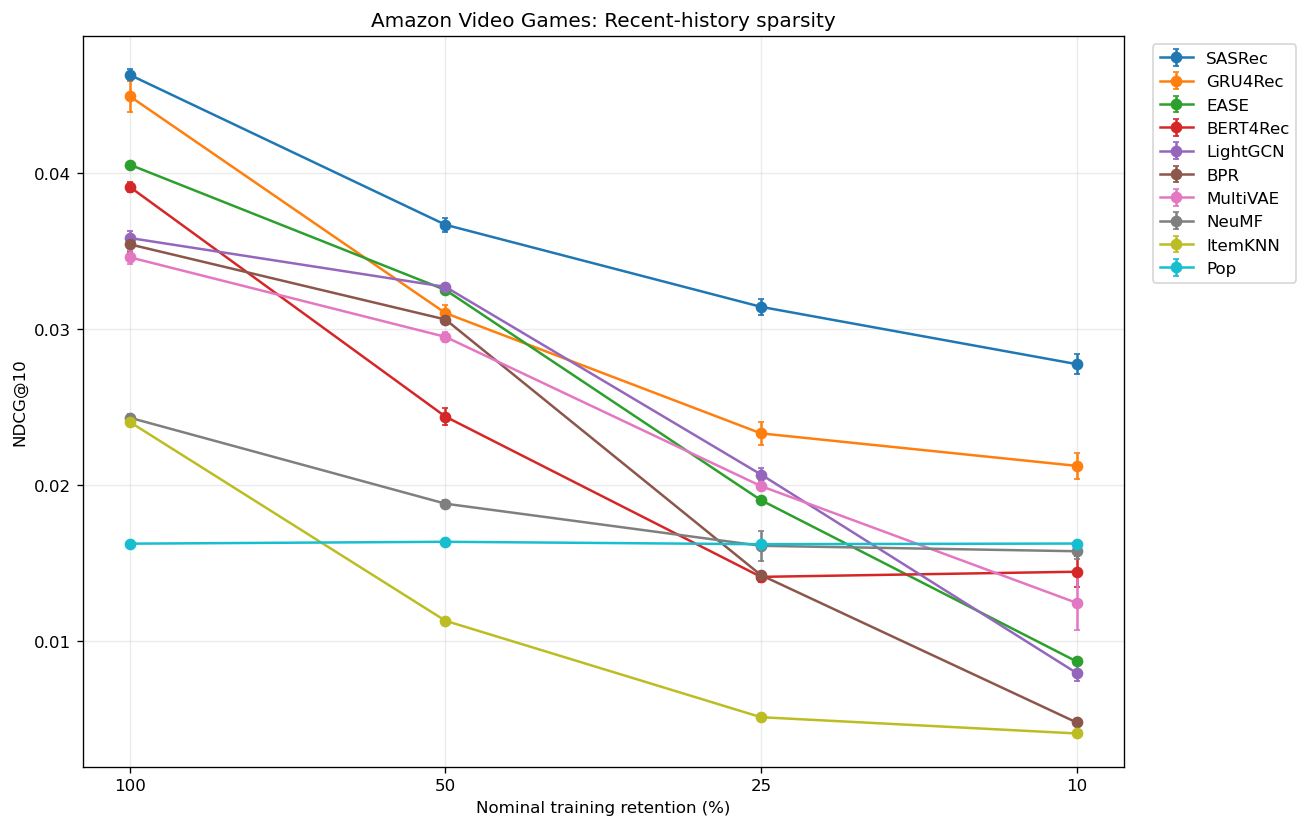

In [20]:
plot_sparsity_curve(
    sparsity_summary,
    dataset="amazon",
    scenario="recent",
    metric="test_ndcg@10",
    metric_label="NDCG@10",
    filename="amazon_recent_ndcg10",
)

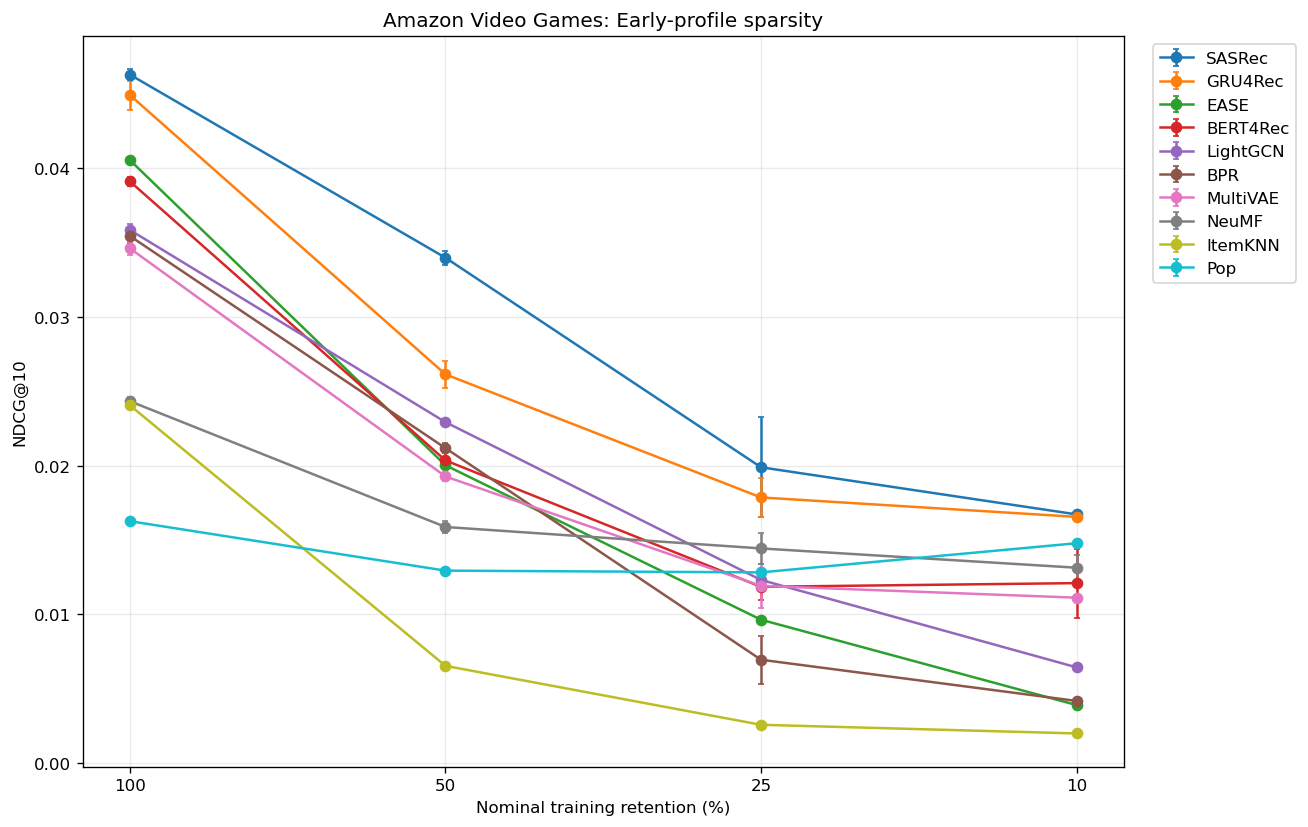

In [21]:
plot_sparsity_curve(
    sparsity_summary,
    dataset="amazon",
    scenario="early",
    metric="test_ndcg@10",
    metric_label="NDCG@10",
    filename="amazon_early_ndcg10",
)

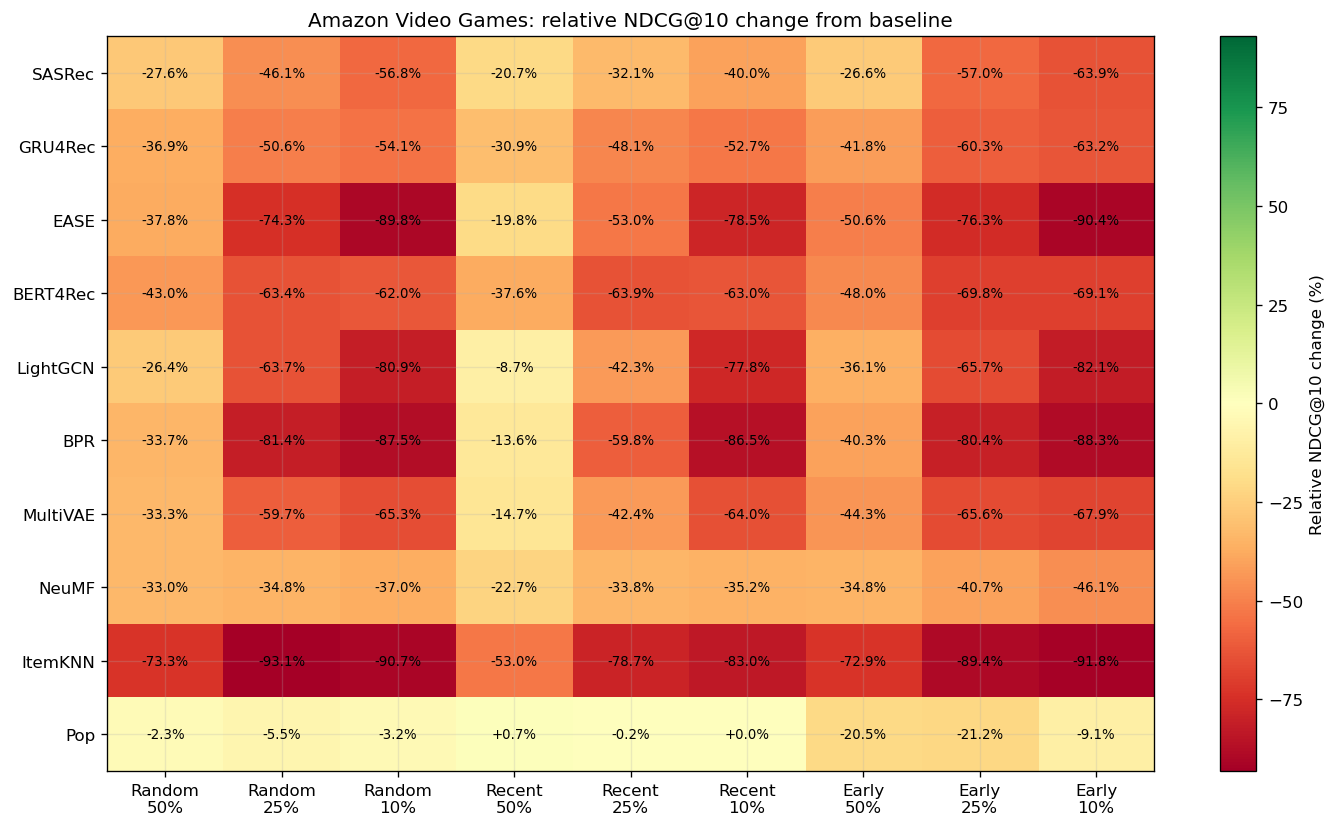

In [22]:
plot_relative_change_heatmap(
    sparsity_summary,
    dataset="amazon",
    filename="amazon_relative_ndcg_change_heatmap",
)

,Model,Family,Baseline,Random 50,Random 25,Random 10,Recent 50,Recent 25,Recent 10,Early 50,Early 25,Early 10
0,SASRec,Sequential,1,1,1,2,1,1,1,1,1,1
1,GRU4Rec,Sequential,2,2,2,1,4,2,2,2,2,2
2,EASE,Linear,3,4,8,9,3,5,7,6,8,9
3,BERT4Rec,Sequential,4,7,5,5,7,9,5,5,7,5
4,LightGCN,Graph,5,3,7,7,2,3,8,3,5,7
5,BPR,Classical,6,5,9,8,5,8,9,4,9,8
6,MultiVAE,Neural,7,6,6,6,6,4,6,7,6,6
7,NeuMF,Neural,8,8,3,4,8,7,4,8,3,4
8,ItemKNN,Classical,9,10,10,10,10,10,10,10,10,10
9,Pop,Non-personalized,10,9,4,3,9,6,3,9,4,3


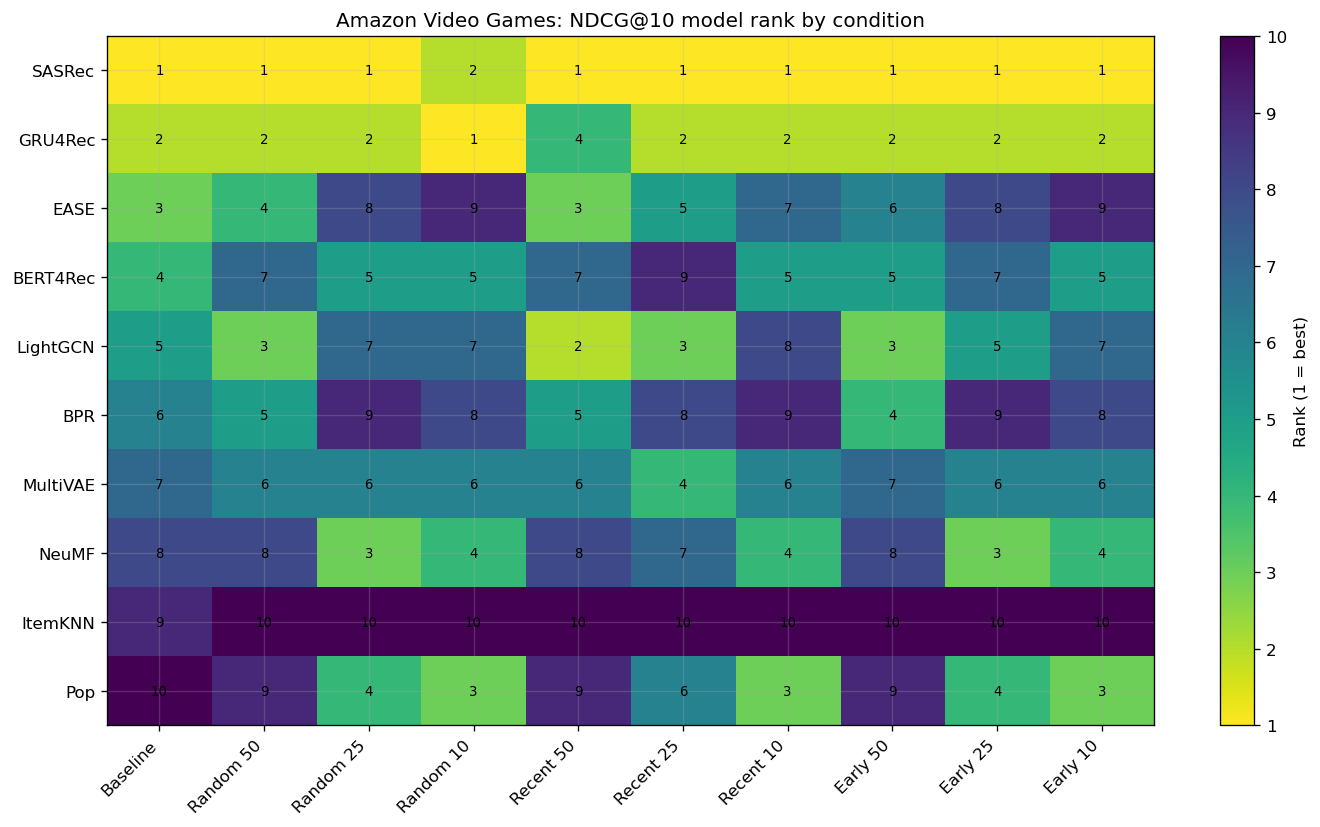

In [23]:
amazon_rank_table = (
    create_rank_table(
        sparsity_summary,
        "amazon",
    )
)

display(
    amazon_rank_table
)

plot_rank_heatmap(
    amazon_rank_table,
    dataset="amazon",
    filename="amazon_ndcg_rank_heatmap",
)

In [24]:
amazon_seed_variability = (
    create_sparse_seed_variability(
        sparsity_summary,
        "amazon",
    )
)

display(
    amazon_seed_variability.head(15)
    .style.format({
        "test_ndcg@10_mean": "{:.6f}",
        "test_ndcg@10_std": "{:.6f}",
        "ndcg_cv_percent": "{:.2f}%",
    })
)

,scenario_label,retention_level,model,test_ndcg@10_mean,test_ndcg@10_std,ndcg_cv_percent
0,Early-profile,25,BPR,0.006928,0.001631,23.54%
1,Early-profile,10,BERT4Rec,0.012086,0.002325,19.23%
2,Early-profile,25,SASRec,0.019885,0.003371,16.95%
3,Recent-history,10,MultiVAE,0.012462,0.001768,14.18%
4,Early-profile,25,MultiVAE,0.011901,0.001465,12.31%
5,Random per-user,10,MultiVAE,0.012034,0.001380,11.47%
6,Random per-user,25,MultiVAE,0.013955,0.001044,7.48%
7,Early-profile,25,BERT4Rec,0.011838,0.000876,7.40%
8,Early-profile,25,GRU4Rec,0.017853,0.001320,7.39%
9,Random per-user,25,BPR,0.006598,0.000485,7.36%


,scenario_label,retention_level,training_unique_items,validation_unseen_percent,test_unseen_percent
0,Baseline,100,18966,0.173%,0.358%
3,Early-profile,50,18184,2.067%,3.331%
2,Early-profile,25,16375,6.204%,8.621%
1,Early-profile,10,14478,10.223%,13.177%
6,Random per-user,50,18565,1.072%,1.667%
5,Random per-user,25,17109,3.703%,4.889%
4,Random per-user,10,15029,7.390%,9.071%
9,Recent-history,50,18604,0.755%,1.116%
8,Recent-history,25,17075,2.916%,3.301%
7,Recent-history,10,14919,6.302%,6.894%


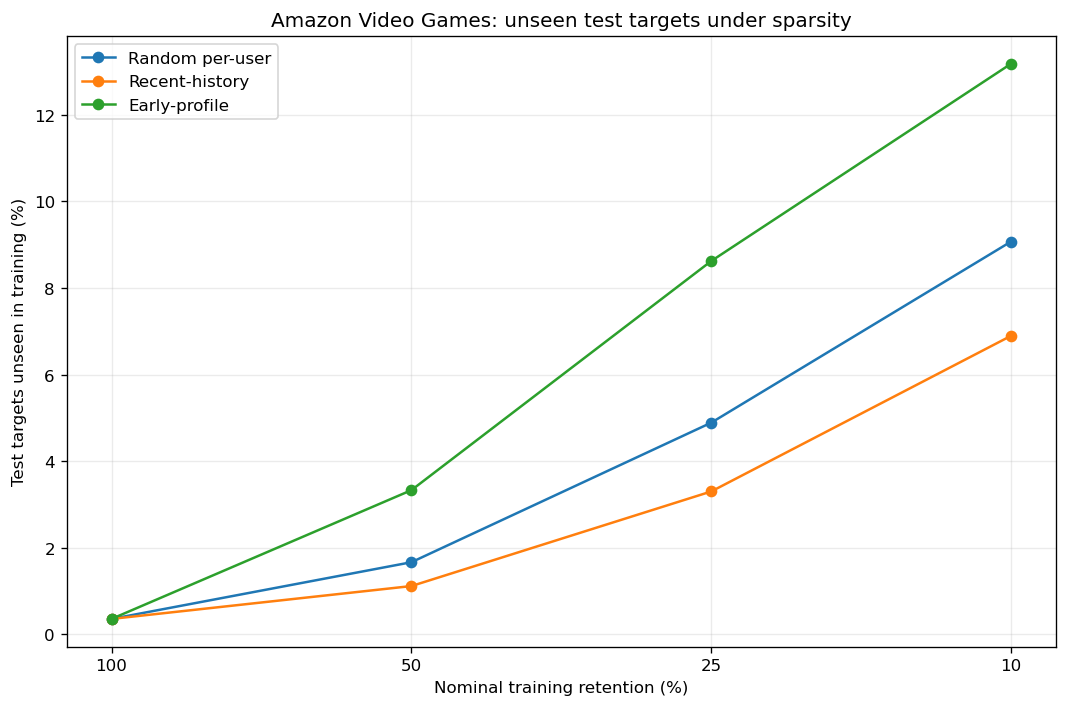

In [25]:
display(
    amazon_conditions[
        [
            "scenario_label",
            "retention_level",
            "training_unique_items",
            "validation_unseen_percent",
            "test_unseen_percent",
        ]
    ]
    .sort_values(
        [
            "scenario_label",
            "retention_level",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .style.format({
        "validation_unseen_percent": "{:.3f}%",
        "test_unseen_percent": "{:.3f}%",
    })
)

plot_unseen_targets(
    condition_data_stats,
    dataset="amazon",
    filename="amazon_unseen_test_targets",
)

In [26]:
amazon_unseen_correlations = (
    unseen_performance_correlations(
        sparsity_summary,
        condition_data_stats,
        "amazon",
    )
)

display(
    amazon_unseen_correlations
    .style.format({
        "Unseen vs NDCG@10": "{:.3f}",
        "Unseen vs Relative Change": "{:.3f}",
    })
)

,Model,Family,Unseen vs NDCG@10,Unseen vs Relative Change
0,Pop,Non-personalized,-0.550,-0.550
1,ItemKNN,Classical,-0.783,-0.783
2,BPR,Classical,-0.933,-0.933
3,EASE,Linear,-0.967,-0.967
4,NeuMF,Neural,-0.983,-0.983
5,MultiVAE,Neural,-0.983,-0.983
6,GRU4Rec,Sequential,-0.967,-0.967
7,SASRec,Sequential,-0.917,-0.917
8,BERT4Rec,Sequential,-0.667,-0.667
9,LightGCN,Graph,-0.967,-0.967


## 4.10 Amazon findings

Record the main Amazon sparsity observations:

- How rapidly does performance decline?
- How does the short Amazon history length affect severe sparsity?
- Which scenario is least damaging?
- Which scenario is most damaging?
- Which models retain the strongest absolute performance?
- Do simple models become relatively more competitive?
- Does Pop appear robust because it depends less on personalized history?
- Which models are particularly sensitive to reduced interaction structure?
- Does seed variability increase?
- How strongly do unseen test targets increase as training data is removed?

These observations will later be converted into the Amazon sparsity subsection of the Results and Discussion chapters.

# 5. Scenario Comparison

## 5.1 Severe sparsity

Directly compare NDCG@10 under the nominal 10% random, recent, and early-profile conditions.

In [27]:
def severe_sparsity_table(
    summary,
    dataset,
):

    sparse = summary[
        (summary["dataset"] == dataset)
        & (
            summary["retention_level"]
            == 10
        )
        & (
            summary["scenario"]
            != "baseline"
        )
    ]

    pivot = sparse.pivot(
        index="model",
        columns="scenario",
        values="test_ndcg@10_mean",
    )

    pivot = pivot.rename(
        columns={
            "global": "Random",
            "recent": "Recent",
            "early": "Early",
        }
    )

    pivot[
        "Best Scenario"
    ] = pivot[
        [
            "Random",
            "Recent",
            "Early",
        ]
    ].idxmax(
        axis=1
    )

    baseline_rank = (
        sparsity_summary[
            (
                sparsity_summary[
                    "dataset"
                ] == dataset
            )
            & (
                sparsity_summary[
                    "scenario"
                ] == "baseline"
            )
        ]
        .set_index("model")[
            "test_ndcg@10_rank"
        ]
    )

    pivot[
        "Baseline Rank"
    ] = baseline_rank

    return (
        pivot
        .reset_index()
        .sort_values(
            "Baseline Rank"
        )
        .reset_index(drop=True)
    )


movielens_severe = (
    severe_sparsity_table(
        sparsity_summary,
        "movielens",
    )
)

amazon_severe = (
    severe_sparsity_table(
        sparsity_summary,
        "amazon",
    )
)


print("MovieLens")
display(
    movielens_severe.style.format({
        "Random": "{:.6f}",
        "Recent": "{:.6f}",
        "Early": "{:.6f}",
    })
)

print("\nAmazon")
display(
    amazon_severe.style.format({
        "Random": "{:.6f}",
        "Recent": "{:.6f}",
        "Early": "{:.6f}",
    })
)

MovieLens


scenario,model,Early,Random,Recent,Best Scenario,Baseline Rank
0,SASRec,0.021299,0.026539,0.054733,Recent,1
1,GRU4Rec,0.013747,0.022897,0.051480,Recent,2
2,BERT4Rec,0.012949,0.017363,0.038849,Recent,3
3,EASE,0.011551,0.011213,0.046078,Recent,4
4,MultiVAE,0.012501,0.011223,0.041512,Recent,5
5,LightGCN,0.009538,0.011183,0.041545,Recent,6
6,BPR,0.011007,0.009634,0.036775,Recent,7
7,ItemKNN,0.008786,0.000957,0.029457,Recent,8
8,NeuMF,0.011035,0.012062,0.034686,Recent,9
9,Pop,0.012014,0.013303,0.017196,Recent,10



Amazon


scenario,model,Early,Random,Recent,Best Scenario,Baseline Rank
0,SASRec,0.016713,0.020016,0.027772,Recent,1
1,GRU4Rec,0.016547,0.020602,0.021246,Recent,2
2,EASE,0.003878,0.004134,0.008705,Recent,3
3,BERT4Rec,0.012086,0.014880,0.014456,Random,4
4,LightGCN,0.006417,0.006863,0.007964,Recent,5
5,BPR,0.004154,0.004441,0.004792,Recent,6
6,MultiVAE,0.011106,0.012034,0.012462,Recent,7
7,NeuMF,0.013123,0.015325,0.015770,Recent,8
8,ItemKNN,0.001965,0.002242,0.004084,Recent,9
9,Pop,0.014770,0.015739,0.016263,Recent,10


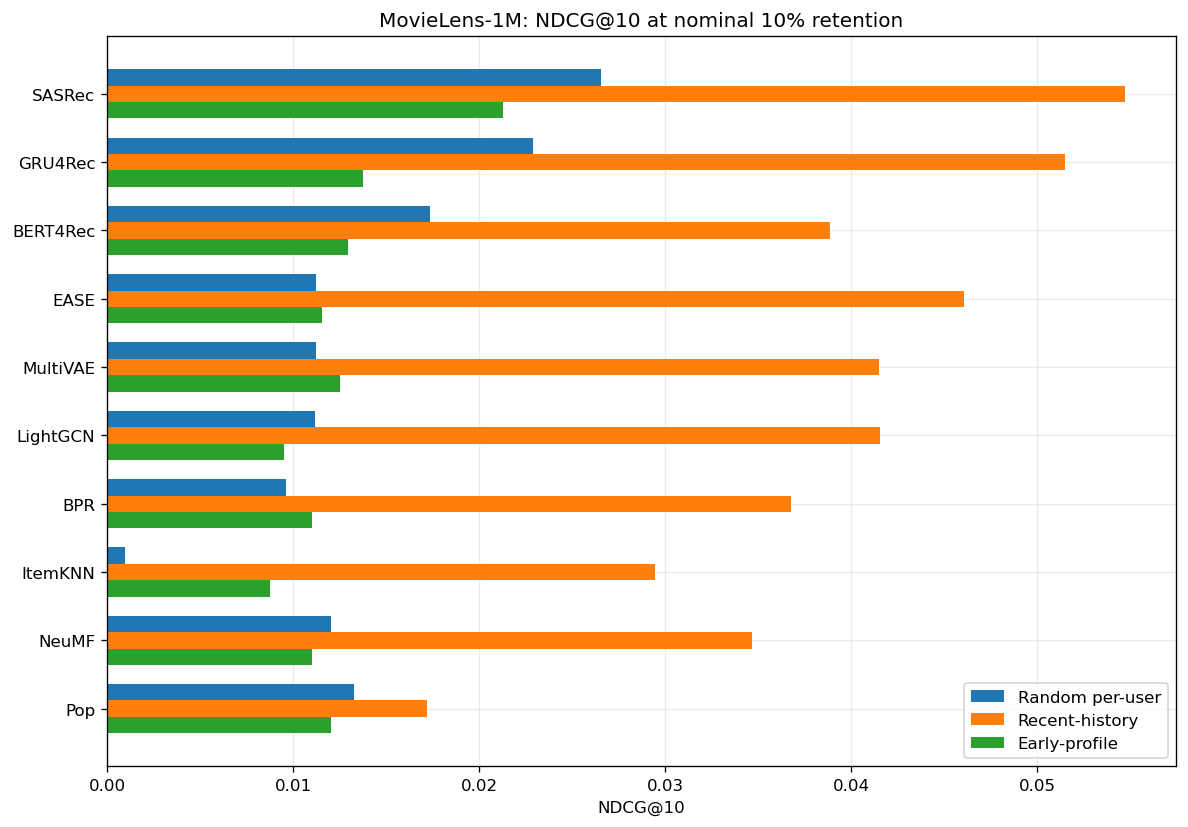

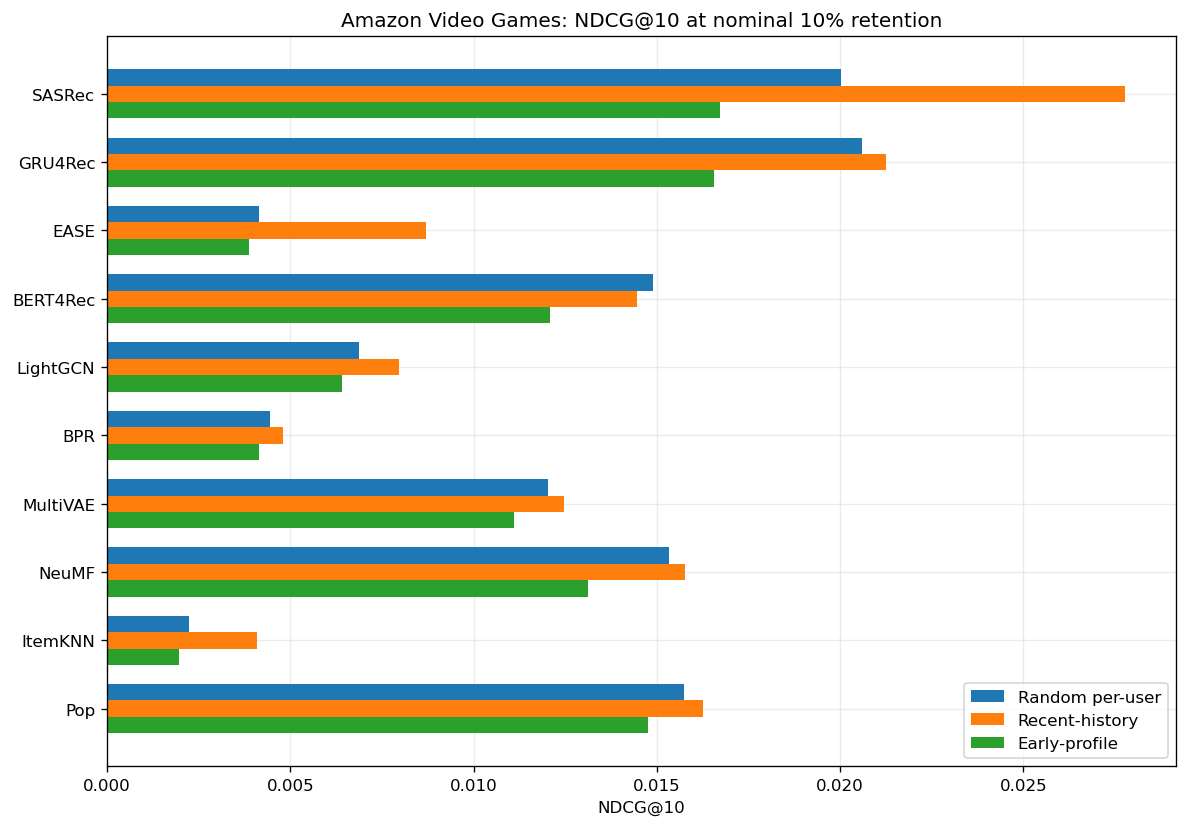

In [28]:
def plot_severe_comparison(
    severe_table,
    dataset,
    filename,
):

    models = severe_table[
        "model"
    ].tolist()

    y = np.arange(
        len(models)
    )

    height = 0.24

    fig, ax = plt.subplots(
        figsize=(10, 7)
    )

    ax.barh(
        y - height,
        severe_table["Random"],
        height=height,
        label="Random per-user",
    )

    ax.barh(
        y,
        severe_table["Recent"],
        height=height,
        label="Recent-history",
    )

    ax.barh(
        y + height,
        severe_table["Early"],
        height=height,
        label="Early-profile",
    )

    ax.set_yticks(
        y,
        models,
    )

    ax.invert_yaxis()

    ax.set_xlabel(
        "NDCG@10"
    )

    dataset_title = (
        "MovieLens-1M"
        if dataset == "movielens"
        else "Amazon Video Games"
    )

    ax.set_title(
        f"{dataset_title}: "
        "NDCG@10 at nominal 10% retention"
    )

    ax.legend()

    fig.tight_layout()

    save_figure(
        fig,
        dataset,
        filename,
    )

    plt.show()


plot_severe_comparison(
    movielens_severe,
    "movielens",
    "movielens_severe_sparsity_comparison",
)

plot_severe_comparison(
    amazon_severe,
    "amazon",
    "amazon_severe_sparsity_comparison",
)

## 5.3 Best sparsity scenario by model

Determine which interaction-retention strategy produces the highest NDCG@10 for each model at 50%, 25%, and 10% nominal retention.

In [29]:
def scenario_winner_table(
    summary,
    dataset,
):

    rows = []

    for retention in [
        50,
        25,
        10,
    ]:

        subset = summary[
            (summary["dataset"] == dataset)
            & (
                summary["retention_level"]
                == retention
            )
            & (
                summary["scenario"]
                != "baseline"
            )
        ]

        pivot = subset.pivot(
            index="model",
            columns="scenario",
            values="test_ndcg@10_mean",
        )

        for model in pivot.index:

            values = pivot.loc[
                model
            ]

            best_scenario = (
                values.idxmax()
            )

            rows.append({
                "Model": model,
                "Retention": retention,
                "Best Scenario": (
                    SCENARIO_LABELS[
                        best_scenario
                    ]
                ),
                "Best NDCG@10": (
                    values.max()
                ),
            })

    return (
        pd.DataFrame(rows)
        .sort_values(
            [
                "Retention",
                "Model",
            ],
            ascending=[
                False,
                True,
            ],
        )
        .reset_index(drop=True)
    )


movielens_scenario_winners = (
    scenario_winner_table(
        sparsity_summary,
        "movielens",
    )
)

amazon_scenario_winners = (
    scenario_winner_table(
        sparsity_summary,
        "amazon",
    )
)


print("MovieLens scenario winners")
display(
    movielens_scenario_winners
)

print("\nAmazon scenario winners")
display(
    amazon_scenario_winners
)

MovieLens scenario winners


,Model,Retention,Best Scenario,Best NDCG@10
0,BERT4Rec,50,Recent-history,0.085193
1,BPR,50,Recent-history,0.032380
2,EASE,50,Recent-history,0.040019
3,GRU4Rec,50,Recent-history,0.090717
4,ItemKNN,50,Recent-history,0.033934
5,LightGCN,50,Recent-history,0.032217
6,MultiVAE,50,Recent-history,0.035683
7,NeuMF,50,Recent-history,0.031859
8,Pop,50,Random per-user,0.015888
9,SASRec,50,Recent-history,0.095992



Amazon scenario winners


,Model,Retention,Best Scenario,Best NDCG@10
0,BERT4Rec,50,Recent-history,0.024402
1,BPR,50,Recent-history,0.030631
2,EASE,50,Recent-history,0.032524
3,GRU4Rec,50,Recent-history,0.031041
4,ItemKNN,50,Recent-history,0.011309
5,LightGCN,50,Recent-history,0.032723
6,MultiVAE,50,Recent-history,0.029517
7,NeuMF,50,Recent-history,0.018819
8,Pop,50,Recent-history,0.016376
9,SASRec,50,Recent-history,0.036706


# 6. Supporting Metric Checks

## 6.1 Metric-ranking consistency

Check whether model rankings based on NDCG@10 are broadly consistent with Recall@10 and MRR@10.

Spearman rank correlation is calculated across the ten models within every experimental condition.

In [30]:
def metric_consistency_table(
    summary,
    dataset,
):

    rows = []

    subset = summary[
        summary["dataset"]
        == dataset
    ]

    for (
        scenario,
        retention,
    ), group in subset.groupby(
        [
            "scenario",
            "retention_level",
        ]
    ):

        rows.append({
            "Condition": condition_label(
                scenario,
                retention,
            ),
            "Scenario": scenario,
            "Retention": retention,
            "NDCG vs Recall": (
                group[
                    "test_ndcg@10_mean"
                ]
                .corr(
                    group[
                        "test_recall@10_mean"
                    ],
                    method="spearman",
                )
            ),
            "NDCG vs MRR": (
                group[
                    "test_ndcg@10_mean"
                ]
                .corr(
                    group[
                        "test_mrr@10_mean"
                    ],
                    method="spearman",
                )
            ),
        })

    return pd.DataFrame(rows)


movielens_metric_consistency = (
    metric_consistency_table(
        sparsity_summary,
        "movielens",
    )
)

amazon_metric_consistency = (
    metric_consistency_table(
        sparsity_summary,
        "amazon",
    )
)


print("MovieLens")
display(
    movielens_metric_consistency
    .style.format({
        "NDCG vs Recall": "{:.3f}",
        "NDCG vs MRR": "{:.3f}",
    })
)

print("\nAmazon")
display(
    amazon_metric_consistency
    .style.format({
        "NDCG vs Recall": "{:.3f}",
        "NDCG vs MRR": "{:.3f}",
    })
)

MovieLens


,Condition,Scenario,Retention,NDCG vs Recall,NDCG vs MRR
0,Baseline,baseline,100,0.988,0.952
1,Early-profile 10%,early,10,0.976,0.964
2,Early-profile 25%,early,25,0.927,0.976
3,Early-profile 50%,early,50,0.988,0.867
4,Random per-user 10%,global,10,0.988,0.952
5,Random per-user 25%,global,25,0.976,1.000
6,Random per-user 50%,global,50,0.964,0.988
7,Recent-history 10%,recent,10,0.988,0.988
8,Recent-history 25%,recent,25,0.988,1.000
9,Recent-history 50%,recent,50,0.988,1.000



Amazon


,Condition,Scenario,Retention,NDCG vs Recall,NDCG vs MRR
0,Baseline,baseline,100,0.988,0.976
1,Early-profile 10%,early,10,1.000,1.000
2,Early-profile 25%,early,25,0.952,0.927
3,Early-profile 50%,early,50,0.988,0.988
4,Random per-user 10%,global,10,0.988,1.000
5,Random per-user 25%,global,25,0.988,1.000
6,Random per-user 50%,global,50,0.988,1.000
7,Recent-history 10%,recent,10,1.000,1.000
8,Recent-history 25%,recent,25,0.976,0.988
9,Recent-history 50%,recent,50,0.964,0.939


## 6.2 Stability across recommendation-list length

Check whether model rankings at NDCG@10 remain consistent with rankings at NDCG@5 and NDCG@20.

In [31]:
def k_consistency_table(
    summary,
    dataset,
):

    rows = []

    subset = summary[
        summary["dataset"]
        == dataset
    ]

    for (
        scenario,
        retention,
    ), group in subset.groupby(
        [
            "scenario",
            "retention_level",
        ]
    ):

        rows.append({
            "Condition": condition_label(
                scenario,
                retention,
            ),
            "NDCG@5 vs NDCG@10": (
                group[
                    "test_ndcg@5_mean"
                ]
                .corr(
                    group[
                        "test_ndcg@10_mean"
                    ],
                    method="spearman",
                )
            ),
            "NDCG@10 vs NDCG@20": (
                group[
                    "test_ndcg@10_mean"
                ]
                .corr(
                    group[
                        "test_ndcg@20_mean"
                    ],
                    method="spearman",
                )
            ),
        })

    return pd.DataFrame(rows)


movielens_k_consistency = (
    k_consistency_table(
        sparsity_summary,
        "movielens",
    )
)

amazon_k_consistency = (
    k_consistency_table(
        sparsity_summary,
        "amazon",
    )
)


print("MovieLens")
display(
    movielens_k_consistency
    .style.format({
        "NDCG@5 vs NDCG@10": "{:.3f}",
        "NDCG@10 vs NDCG@20": "{:.3f}",
    })
)

print("\nAmazon")
display(
    amazon_k_consistency
    .style.format({
        "NDCG@5 vs NDCG@10": "{:.3f}",
        "NDCG@10 vs NDCG@20": "{:.3f}",
    })
)

MovieLens


,Condition,NDCG@5 vs NDCG@10,NDCG@10 vs NDCG@20
0,Baseline,0.988,0.988
1,Early-profile 10%,0.939,0.952
2,Early-profile 25%,0.976,0.794
3,Early-profile 50%,0.842,0.927
4,Random per-user 10%,0.952,0.988
5,Random per-user 25%,0.988,0.988
6,Random per-user 50%,0.988,1.000
7,Recent-history 10%,0.988,1.000
8,Recent-history 25%,1.000,0.988
9,Recent-history 50%,1.000,0.988



Amazon


,Condition,NDCG@5 vs NDCG@10,NDCG@10 vs NDCG@20
0,Baseline,0.976,0.988
1,Early-profile 10%,0.988,0.988
2,Early-profile 25%,0.915,0.964
3,Early-profile 50%,0.988,0.988
4,Random per-user 10%,0.964,1.000
5,Random per-user 25%,1.000,1.000
6,Random per-user 50%,1.000,1.000
7,Recent-history 10%,0.988,1.000
8,Recent-history 25%,0.988,0.988
9,Recent-history 50%,0.976,0.988


# 7. Export Results

## 7.1 Export analysis tables

Save all major sparsity-analysis tables so that dissertation outputs can later be regenerated directly from these results.

In [32]:
sparsity_summary.to_csv(
    TABLE_DIR
    / "sparsity_summary_full.csv",
    index=False,
)

condition_data_stats.to_csv(
    TABLE_DIR
    / "condition_data_statistics.csv",
    index=False,
)

movielens_conditions.to_csv(
    TABLE_DIR
    / "movielens_condition_statistics.csv",
    index=False,
)

amazon_conditions.to_csv(
    TABLE_DIR
    / "amazon_condition_statistics.csv",
    index=False,
)

movielens_rank_table.to_csv(
    TABLE_DIR
    / "movielens_ndcg_rank_by_condition.csv",
    index=False,
)

amazon_rank_table.to_csv(
    TABLE_DIR
    / "amazon_ndcg_rank_by_condition.csv",
    index=False,
)

movielens_seed_variability.to_csv(
    TABLE_DIR
    / "movielens_sparse_seed_variability.csv",
    index=False,
)

amazon_seed_variability.to_csv(
    TABLE_DIR
    / "amazon_sparse_seed_variability.csv",
    index=False,
)

movielens_unseen_correlations.to_csv(
    TABLE_DIR
    / "movielens_unseen_target_correlations.csv",
    index=False,
)

amazon_unseen_correlations.to_csv(
    TABLE_DIR
    / "amazon_unseen_target_correlations.csv",
    index=False,
)

movielens_severe.to_csv(
    TABLE_DIR
    / "movielens_severe_sparsity.csv",
    index=False,
)

amazon_severe.to_csv(
    TABLE_DIR
    / "amazon_severe_sparsity.csv",
    index=False,
)

movielens_scenario_winners.to_csv(
    TABLE_DIR
    / "movielens_scenario_winners.csv",
    index=False,
)

amazon_scenario_winners.to_csv(
    TABLE_DIR
    / "amazon_scenario_winners.csv",
    index=False,
)

movielens_metric_consistency.to_csv(
    TABLE_DIR
    / "movielens_metric_consistency.csv",
    index=False,
)

amazon_metric_consistency.to_csv(
    TABLE_DIR
    / "amazon_metric_consistency.csv",
    index=False,
)

movielens_k_consistency.to_csv(
    TABLE_DIR
    / "movielens_k_consistency.csv",
    index=False,
)

amazon_k_consistency.to_csv(
    TABLE_DIR
    / "amazon_k_consistency.csv",
    index=False,
)


print("Sparsity tables saved:")
for path in sorted(
    TABLE_DIR.glob("*.csv")
):
    print(
        f"  {path.relative_to(ROOT)}"
    )


print("\nSparsity figures saved:")
for dataset in [
    "movielens",
    "amazon",
]:
    for path in sorted(
        (FIGURE_DIR / dataset).glob("*")
    ):
        print(
            f"  {path.relative_to(ROOT)}"
        )

Sparsity tables saved:
  results\tables\sparsity\amazon_condition_statistics.csv
  results\tables\sparsity\amazon_k_consistency.csv
  results\tables\sparsity\amazon_metric_consistency.csv
  results\tables\sparsity\amazon_ndcg_rank_by_condition.csv
  results\tables\sparsity\amazon_scenario_winners.csv
  results\tables\sparsity\amazon_severe_sparsity.csv
  results\tables\sparsity\amazon_sparse_seed_variability.csv
  results\tables\sparsity\amazon_unseen_target_correlations.csv
  results\tables\sparsity\condition_data_statistics.csv
  results\tables\sparsity\movielens_condition_statistics.csv
  results\tables\sparsity\movielens_k_consistency.csv
  results\tables\sparsity\movielens_metric_consistency.csv
  results\tables\sparsity\movielens_ndcg_rank_by_condition.csv
  results\tables\sparsity\movielens_scenario_winners.csv
  results\tables\sparsity\movielens_severe_sparsity.csv
  results\tables\sparsity\movielens_sparse_seed_variability.csv
  results\tables\sparsity\movielens_unseen_target_

# 8. Sparsity Analysis Summary

## 8.1 NDCG@10 condition winners

Identify the highest-performing model under every sparse condition.

In [33]:
print("=" * 78)
print("SPARSITY ANALYSIS COMPLETE")
print("=" * 78)

for dataset in [
    "movielens",
    "amazon",
]:

    print(
        f"\n{dataset.upper()}"
    )

    subset = sparsity_summary[
        (sparsity_summary["dataset"] == dataset)
        & (
            sparsity_summary["scenario"]
            != "baseline"
        )
    ]

    for scenario in SPARSE_SCENARIOS:

        print(
            f"\n{SCENARIO_LABELS[scenario]}"
        )

        for retention in [
            50,
            25,
            10,
        ]:

            condition = subset[
                (
                    subset["scenario"]
                    == scenario
                )
                & (
                    subset["retention_level"]
                    == retention
                )
            ].sort_values(
                "test_ndcg@10_mean",
                ascending=False,
            )

            winner = (
                condition.iloc[0]
            )

            print(
                f"  {retention:>2}% | "
                f"{winner['model']:<9} | "
                f"NDCG@10 = "
                f"{winner['test_ndcg@10_mean']:.6f}"
            )

print()
print(
    "Sparsity tables and figures are ready "
    "for interpretation and cross-dataset analysis."
)

SPARSITY ANALYSIS COMPLETE

MOVIELENS

Random per-user
  50% | SASRec    | NDCG@10 = 0.083323
  25% | GRU4Rec   | NDCG@10 = 0.055318
  10% | SASRec    | NDCG@10 = 0.026539

Recent-history
  50% | SASRec    | NDCG@10 = 0.095992
  25% | GRU4Rec   | NDCG@10 = 0.074018
  10% | SASRec    | NDCG@10 = 0.054733

Early-profile
  50% | SASRec    | NDCG@10 = 0.046350
  25% | SASRec    | NDCG@10 = 0.032298
  10% | SASRec    | NDCG@10 = 0.021299

AMAZON

Random per-user
  50% | SASRec    | NDCG@10 = 0.033523
  25% | SASRec    | NDCG@10 = 0.024978
  10% | GRU4Rec   | NDCG@10 = 0.020602

Recent-history
  50% | SASRec    | NDCG@10 = 0.036706
  25% | SASRec    | NDCG@10 = 0.031443
  10% | SASRec    | NDCG@10 = 0.027772

Early-profile
  50% | SASRec    | NDCG@10 = 0.033990
  25% | SASRec    | NDCG@10 = 0.019885
  10% | SASRec    | NDCG@10 = 0.016713

Sparsity tables and figures are ready for interpretation and cross-dataset analysis.
